In [1]:
import numpy as np
import pandas as pd
import torch
import os
import matplotlib.pyplot as plt

d:\Program Files\anaconda3\envs\torch126\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
import sys

from flare_preprocessing import *
from utilities import *

In [4]:
%load_ext autoreload
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
working_dir = 'D:/2024_S1/ML_SEP_2402/Final_update/Open_Repo'
opr = opr_data_preprocessing(working_dir + "/data/v2_ftp_flares_1997_2024.csv")
sci = sci_data_preprocessing(working_dir + "/data/Sci_matched_with_assigned_ar_20100101_20241231.csv", opr)

Shape of the operation data: (25364, 9)
Shape of the science-quality data: (32675, 26)


d:\2024_S1\ML_SEP_2402\Final_update\Open_Repo\2607Revision\utilities.py:64: RuntimeWarning: divide by zero encountered in log10
  return np.log10(intensity * 10 ** -8)


# Samples

## NRT sharps

In [9]:
from New_SampleConstruction import *

In [10]:
from pathlib import Path

def read_all_harp_csvs(root: str | Path, recursive: bool = False) -> pd.DataFrame:
    """
    Read all per-HARP CSVs under `root`, concatenate them in ascending HARP order,
    Assumes files are named like HARP_<harpnum>.csv.
    """

    root = Path(root)
    pattern = "**/HARP_*.csv" if recursive else "HARP_*.csv"

    # List files first, sorted by HARP number
    harp_files = []
    for f in root.glob(pattern):
        try:
            harpnum = int(f.stem.split("_")[1])
            harp_files.append((harpnum, f))
        except Exception:
            continue

    # sort by numeric harp number
    harp_files.sort(key=lambda x: x[0])

    frames = []

    for harpnum, f in harp_files:
        # read with T_REC parsed as datetime
        df = pd.read_csv(f, parse_dates=["T_REC"])
        print(f"Reading HARP {harpnum}")

        # Skip if the HARP lifetime is less than 120 rows (24h / 12min cadence)
        if len(df) < 120:
            print(f"  -> Skipping HARP {harpnum} (too short)")
            continue
        # fill the HARPNUM with the harpnum
        df['HARPNUM'] = harpnum
        frames.append(df)

    if not frames:
        print("No valid HARP CSVs found.")
        return pd.DataFrame()

    # Concatenate in correct order
    full_df = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(frames)} HARPs; total rows = {len(full_df)}")
    
    return full_df

In [7]:
nrt_sharps = read_all_harp_csvs(r"D:\\Input Data\\Operational Data\\HMI\SHARP_by_HARP")

Reading HARP 476
Reading HARP 487
Reading HARP 493
Reading HARP 495
Reading HARP 497
Reading HARP 498
Reading HARP 499
  -> Skipping HARP 499 (too short)
Reading HARP 500
  -> Skipping HARP 500 (too short)
Reading HARP 501
Reading HARP 502
Reading HARP 503
Reading HARP 504
Reading HARP 505
Reading HARP 506
  -> Skipping HARP 506 (too short)
Reading HARP 508
Reading HARP 509
Reading HARP 510
Reading HARP 511
Reading HARP 512
Reading HARP 513
  -> Skipping HARP 513 (too short)
Reading HARP 514
  -> Skipping HARP 514 (too short)
Reading HARP 515
Reading HARP 516
Reading HARP 518
  -> Skipping HARP 518 (too short)
Reading HARP 520
Reading HARP 521
Reading HARP 523
Reading HARP 524
  -> Skipping HARP 524 (too short)
Reading HARP 526
Reading HARP 527
Reading HARP 529
Reading HARP 532
Reading HARP 533
  -> Skipping HARP 533 (too short)
Reading HARP 534
Reading HARP 537
Reading HARP 547
  -> Skipping HARP 547 (too short)
Reading HARP 550
Reading HARP 552
  -> Skipping HARP 552 (too short)
Read

C:\Users\huke0\AppData\Local\Temp\ipykernel_25380\2427577827.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f, parse_dates=["T_REC"])


Reading HARP 11094
  -> Skipping HARP 11094 (too short)
Reading HARP 11095
  -> Skipping HARP 11095 (too short)
Reading HARP 11096
  -> Skipping HARP 11096 (too short)
Reading HARP 11097
Reading HARP 11098
Reading HARP 11099
Reading HARP 11100
Reading HARP 11101
Reading HARP 11102
Reading HARP 11103
  -> Skipping HARP 11103 (too short)
Reading HARP 11104
Reading HARP 11105
Reading HARP 11106
  -> Skipping HARP 11106 (too short)
Reading HARP 11107
  -> Skipping HARP 11107 (too short)
Reading HARP 11108
  -> Skipping HARP 11108 (too short)
Reading HARP 11123
  -> Skipping HARP 11123 (too short)
Reading HARP 11172
Reading HARP 11174
Reading HARP 11197
Reading HARP 11199
Reading HARP 11200
Reading HARP 11203
Reading HARP 11207
  -> Skipping HARP 11207 (too short)
Reading HARP 11209
Reading HARP 11210
Reading HARP 11211
  -> Skipping HARP 11211 (too short)
Reading HARP 11212
  -> Skipping HARP 11212 (too short)
Reading HARP 11215
Reading HARP 11217
Reading HARP 11218
Reading HARP 11219
Read

In [22]:
# delete rows with key columns any NaN values
key_columns = [
    'USFLUX','MEANGAM','MEANGBT','MEANGBZ','MEANGBH','MEANJZD',
    'TOTUSJZ','MEANALP','MEANJZH','TOTUSJH','ABSNJZH','SAVNCPP',
    'MEANPOT','TOTPOT','MEANSHR','SHRGT45','SIZE','SIZE_ACR',
    'NACR','NPIX'
]
nrt_sharps = nrt_sharps.dropna(subset=key_columns)

In [23]:
nowcast_sci_nrt = New_SampleConstruction()
nowcast_sci_nrt.samples_from_harp(sci, nrt_sharps, lead_window=0)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [25]:
nowcast_opr_nrt = New_SampleConstruction()
nowcast_opr_nrt.samples_from_harp(opr, nrt_sharps, lead_window=0)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [26]:
lead6_sci_nrt = New_SampleConstruction()
lead6_sci_nrt.samples_from_harp(sci, nrt_sharps, lead_window=6)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [27]:
lead6_opr_nrt = New_SampleConstruction()
lead6_opr_nrt.samples_from_harp(opr, nrt_sharps, lead_window=6)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [28]:
lead12_sci_nrt = New_SampleConstruction()
lead12_sci_nrt.samples_from_harp(sci, nrt_sharps, lead_window=12)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [29]:
lead12_opr_nrt = New_SampleConstruction()
lead12_opr_nrt.samples_from_harp(opr, nrt_sharps, lead_window=12)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [30]:
lead24_sci_nrt = New_SampleConstruction()
lead24_sci_nrt.samples_from_harp(sci, nrt_sharps, lead_window=24)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [31]:
lead24_opr_nrt = New_SampleConstruction()
lead24_opr_nrt.samples_from_harp(opr, nrt_sharps, lead_window=24)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

# LSTM Models

In [13]:
from New_lstm2 import *

## Task 1

get samples
Using all training samples: 341 positives and 730 negatives.
BCE positive-class weight: 2.1408
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9402177110314369
Epoch 2, avg loss: 0.9044595584273338
Epoch 3, avg loss: 0.8703762516379356
Epoch 4, avg loss: 0.8022343218326569
Epoch 5, avg loss: 0.7275223881006241
Epoch 6, avg loss: 0.6528044641017914
Epoch 7, avg loss: 0.5781724974513054
Epoch 8, avg loss: 0.5232706665992737
Epoch 9, avg loss: 0.48750874772667885
Epoch 10, avg loss: 0.45546483248472214
Epoch 11, avg loss: 0.45707694068551064
Epoch 12, avg loss: 0.427154827862978
Epoch 13, avg loss: 0.3928318079560995
Epoch 14, avg loss: 0.4000367633998394
Epoch 15, avg loss: 0.401915717869997
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9442395940423012
Epoch 2, avg loss: 0.9156486317515373
Epoch 3, avg loss: 0.8788088858127594
Epoch 4, avg loss: 0.8283080980181694
Epoch 5, avg loss: 0.7584267556667328
Epoch 6, avg loss: 0.6760395765304565
Epoch 7, avg loss: 0.5946371778845787


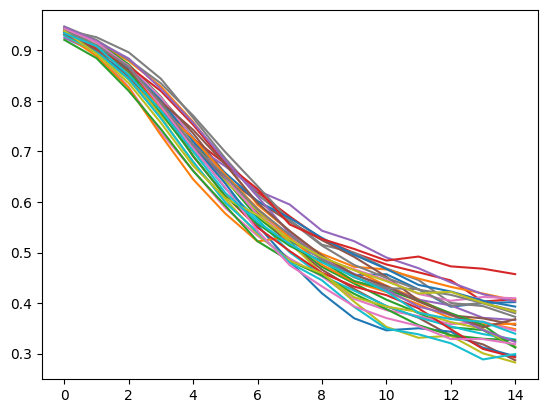

The 95% CI for threshold is 0.15000000000000002 - 0.86375
The chosen threshold: 0.5116666666666666
The 95% CI for TSS is 0.6576510721247564 - 0.8593242365172189

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 41.39 seconds
Max CPU memory used: 4050.55 MB
Max GPU memory used: 371.53 MB


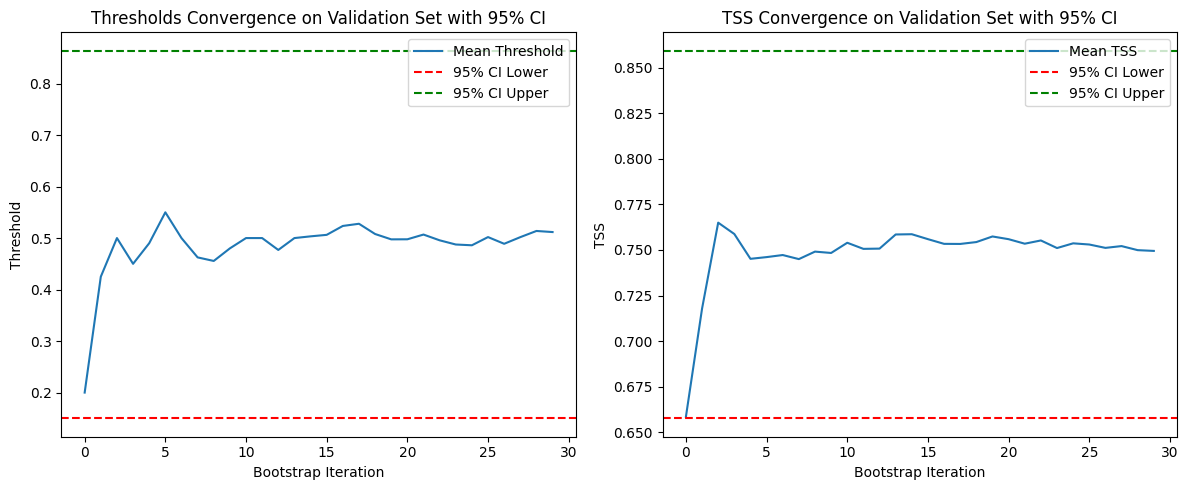

In [24]:
nowcast_Task1_sci_nrt = train_lstm()
nowcast_Task1_sci_nrt.train(nowcast_sci_nrt.inputs_profile, nowcast_sci_nrt.labels, "Task1", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [32]:
save_dir = ".\\LSTM_models\\Task1_sci_nrt_models"

for i, model in enumerate(nowcast_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"nowcast_Task1_sci_nrt{i}_{np.mean(nowcast_Task1_sci_nrt.thresholds)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using all training samples: 275 positives and 937 negatives.
BCE positive-class weight: 3.4073
Bootstrap iteration 1/30
Epoch 1, avg loss: 1.0315073198742337
Epoch 2, avg loss: 0.9907565646701388
Epoch 3, avg loss: 0.9132505456606547
Epoch 4, avg loss: 0.8226915001869202
Epoch 5, avg loss: 0.7592125270101759
Epoch 6, avg loss: 0.6840325461493598
Epoch 7, avg loss: 0.6078128616015116
Epoch 8, avg loss: 0.5452300310134888
Epoch 9, avg loss: 0.48393711778852677
Epoch 10, avg loss: 0.4356567594740126
Epoch 11, avg loss: 0.4298579494158427
Epoch 12, avg loss: 0.38027657402886283
Epoch 13, avg loss: 0.38530192772547406
Epoch 14, avg loss: 0.3666178219848209
Epoch 15, avg loss: 0.350956314139896
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.0726959307988484
Epoch 2, avg loss: 1.0377990338537428
Epoch 3, avg loss: 0.9758265548282199
Epoch 4, avg loss: 0.895871188905504
Epoch 5, avg loss: 0.8248206641938951
Epoch 6, avg loss: 0.7548325326707628
Epoch 7, avg loss: 0.6947704023785062


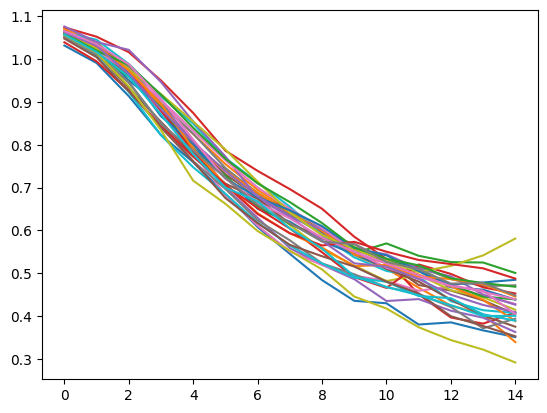

The 95% CI for threshold is 0.2225 - 0.9
The chosen threshold: 0.6066666666666667
The 95% CI for TSS is 0.7695254342431762 - 0.9024813895781637

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 48.67 seconds
Max CPU memory used: 8147.75 MB
Max GPU memory used: 373.53 MB


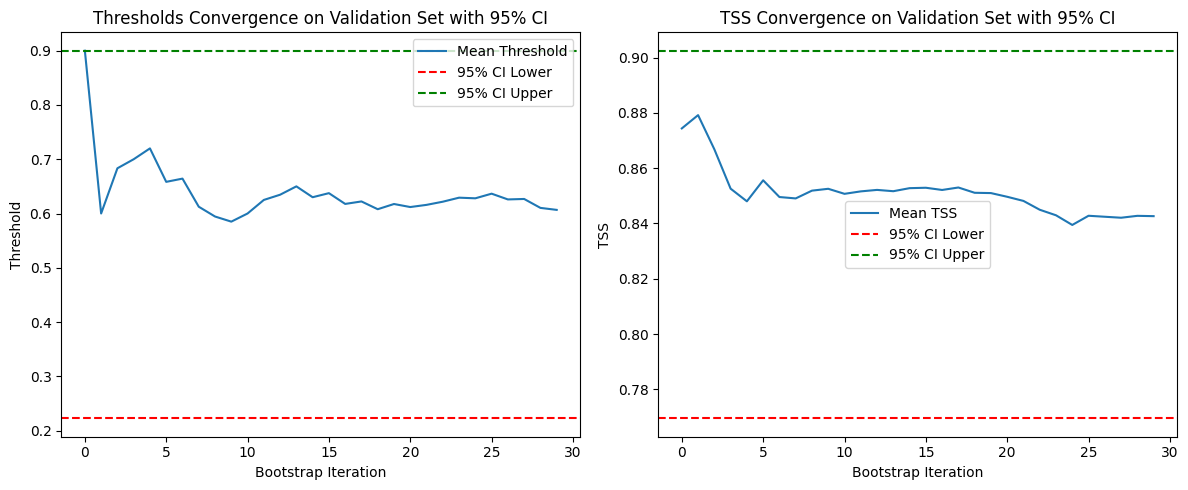

In [33]:
nowcast_Task1_opr_nrt = train_lstm()
nowcast_Task1_opr_nrt.train(nowcast_opr_nrt.inputs_profile, nowcast_opr_nrt.labels, "Task1", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [34]:
save_dir = ".\\LSTM_models\\Task1_opr_nrt_models"

for i, model in enumerate(nowcast_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"nowcast_Task1_opr_nrt{i}_{np.round(np.mean(nowcast_Task1_opr_nrt.thresholds),2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using all training samples: 320 positives and 716 negatives.
BCE positive-class weight: 2.2375
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9488077834248543
Epoch 2, avg loss: 0.9120607450604439
Epoch 3, avg loss: 0.8681565970182419
Epoch 4, avg loss: 0.8058837428689003
Epoch 5, avg loss: 0.7337973341345787
Epoch 6, avg loss: 0.6697824969887733
Epoch 7, avg loss: 0.6069633290171623
Epoch 8, avg loss: 0.5479913093149662
Epoch 9, avg loss: 0.4977593347430229
Epoch 10, avg loss: 0.45977966487407684
Epoch 11, avg loss: 0.4394065849483013
Epoch 12, avg loss: 0.4384719803929329
Epoch 13, avg loss: 0.4305957034230232
Epoch 14, avg loss: 0.41917721927165985
Epoch 15, avg loss: 0.4004959426820278
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9435635879635811
Epoch 2, avg loss: 0.9219937324523926
Epoch 3, avg loss: 0.8712533265352249
Epoch 4, avg loss: 0.8226163983345032
Epoch 5, avg loss: 0.7633400931954384
Epoch 6, avg loss: 0.7152403146028519
Epoch 7, avg loss: 0.6753046736121178

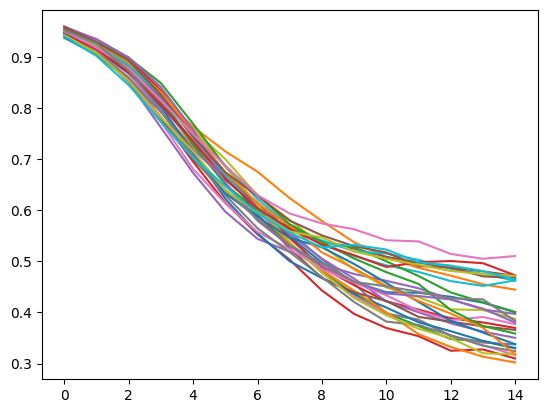

The 95% CI for threshold is 0.17250000000000001 - 0.81375
The chosen threshold: 0.4183333333333333
The 95% CI for TSS is 0.6437152777777778 - 0.8415625

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 42.44 seconds
Max CPU memory used: 8128.48 MB
Max GPU memory used: 377.53 MB


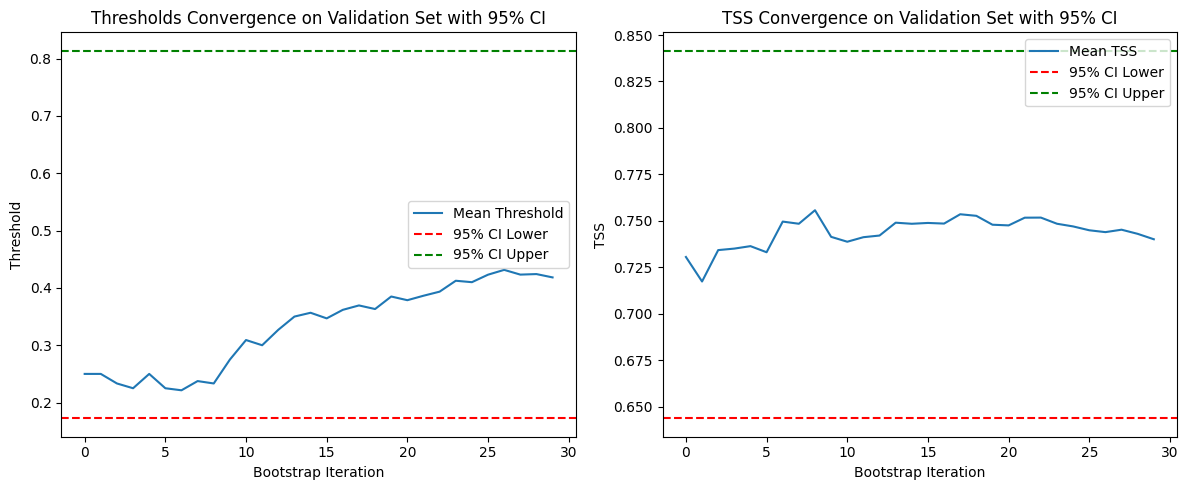

In [35]:
lead6_Task1_sci_nrt = train_lstm()
lead6_Task1_sci_nrt.train(lead6_sci_nrt.inputs_profile, lead6_sci_nrt.labels, "Task1", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [36]:
save_dir = ".\\LSTM_models\\Task1_sci_nrt_models"

for i, model in enumerate(lead6_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead6_Task1_sci_nrt{i}_{np.mean(lead6_Task1_sci_nrt.thresholds)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using all training samples: 258 positives and 922 negatives.
BCE positive-class weight: 3.5736
Bootstrap iteration 1/30
Epoch 1, avg loss: 1.0786849392784967
Epoch 2, avg loss: 1.0427310400538974
Epoch 3, avg loss: 0.9945613808102078
Epoch 4, avg loss: 0.9228053357866075
Epoch 5, avg loss: 0.8466717667049832
Epoch 6, avg loss: 0.7421152393023173
Epoch 7, avg loss: 0.6479597025447421
Epoch 8, avg loss: 0.5881141622861227
Epoch 9, avg loss: 0.5696913798650106
Epoch 10, avg loss: 0.5180431339475844
Epoch 11, avg loss: 0.4885658125082652
Epoch 12, avg loss: 0.4564185639222463
Epoch 13, avg loss: 0.44571871558825177
Epoch 14, avg loss: 0.42153938942485386
Epoch 15, avg loss: 0.4289071990383996
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.0719376471307542
Epoch 2, avg loss: 1.0405832065476313
Epoch 3, avg loss: 0.981683353583018
Epoch 4, avg loss: 0.9056144422954984
Epoch 5, avg loss: 0.832613832420773
Epoch 6, avg loss: 0.7502511541048685
Epoch 7, avg loss: 0.6962662405437894
E

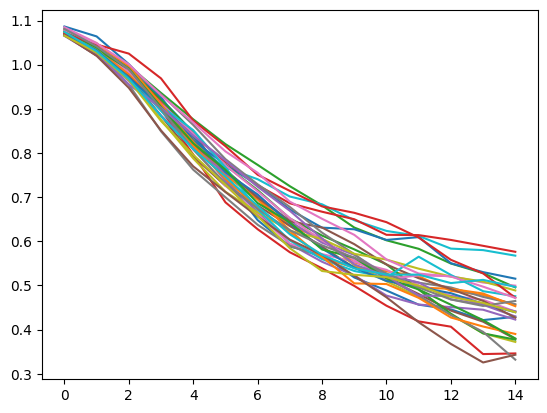

The 95% CI for threshold is 0.13625 - 0.81375
The chosen threshold: 0.44000000000000006
The 95% CI for TSS is 0.7598844994978239 - 0.9194174757281554

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 49.75 seconds
Max CPU memory used: 8152.05 MB
Max GPU memory used: 379.53 MB


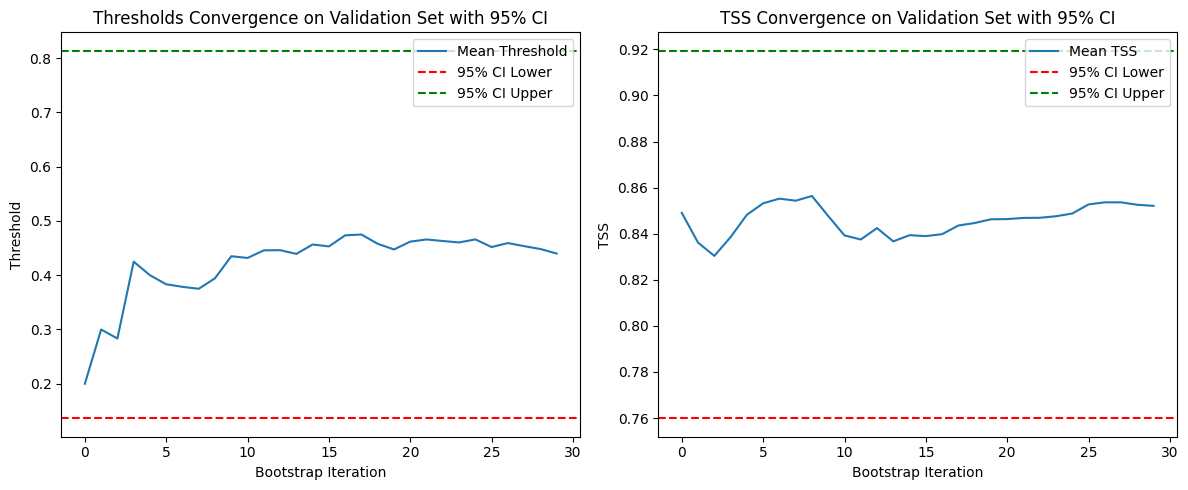

In [37]:
lead6_Task1_opr_nrt = train_lstm()
lead6_Task1_opr_nrt.train(lead6_opr_nrt.inputs_profile, lead6_opr_nrt.labels, "Task1", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [38]:
save_dir = ".\\LSTM_models\\Task1_opr_nrt_models"

for i, model in enumerate(lead6_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead6_Task1_opr_nrt{i}_{np.round(np.mean(lead6_Task1_opr_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using all training samples: 302 positives and 679 negatives.
BCE positive-class weight: 2.2483
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9591999139104571
Epoch 2, avg loss: 0.939519831112453
Epoch 3, avg loss: 0.9199595195906503
Epoch 4, avg loss: 0.8996439405850002
Epoch 5, avg loss: 0.8581862449645996
Epoch 6, avg loss: 0.8156964608601162
Epoch 7, avg loss: 0.7517685379300799
Epoch 8, avg loss: 0.6921949812344143
Epoch 9, avg loss: 0.6779356939452035
Epoch 10, avg loss: 0.6147991929735456
Epoch 11, avg loss: 0.6008931994438171
Epoch 12, avg loss: 0.5317282974720001
Epoch 13, avg loss: 0.5162269813673837
Epoch 14, avg loss: 0.46848297119140625
Epoch 15, avg loss: 0.4669453373977116
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9532365798950195
Epoch 2, avg loss: 0.9286964365414211
Epoch 3, avg loss: 0.9014482157570975
Epoch 4, avg loss: 0.8587362766265869
Epoch 5, avg loss: 0.8128815974508014
Epoch 6, avg loss: 0.7535663672855922
Epoch 7, avg loss: 0.6900894556726728
E

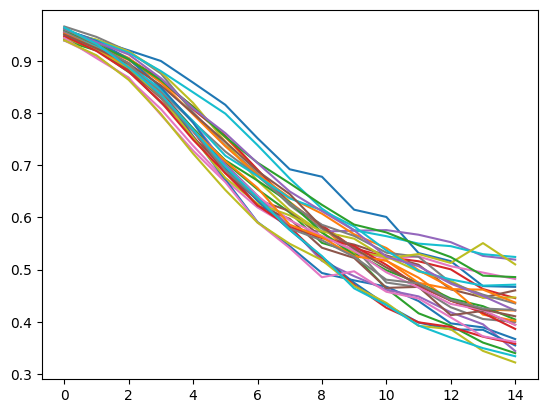

The 95% CI for threshold is 0.17250000000000001 - 0.86375
The chosen threshold: 0.44833333333333336
The 95% CI for TSS is 0.7424117647058823 - 0.8593529411764705

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 36.64 seconds
Max CPU memory used: 8125.27 MB
Max GPU memory used: 385.53 MB


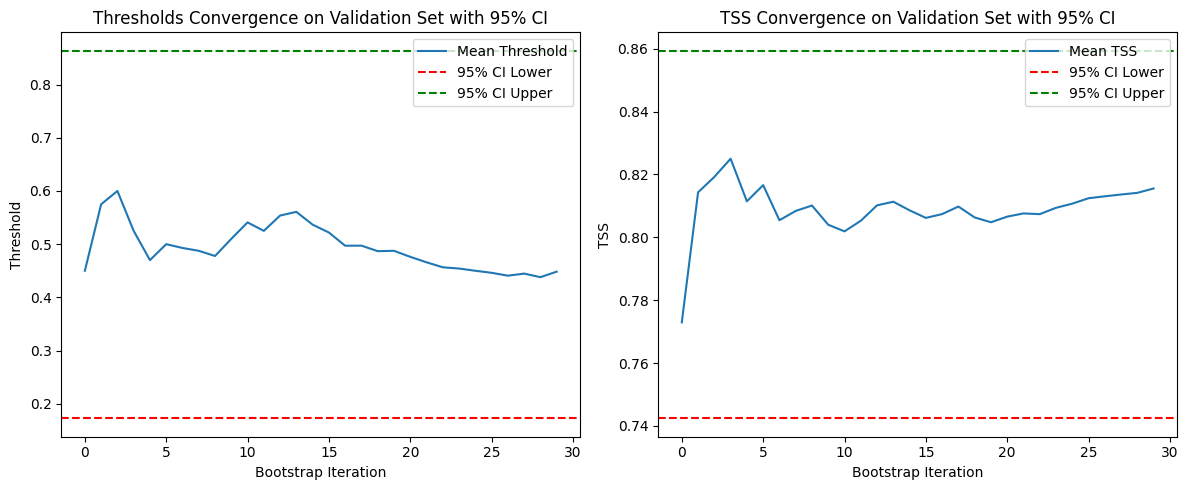

In [39]:
lead12_Task1_sci_nrt = train_lstm()
lead12_Task1_sci_nrt.train(lead12_sci_nrt.inputs_profile, lead12_sci_nrt.labels, "Task1", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [40]:
save_dir = ".\\LSTM_models\\Task1_sci_nrt_models"

for i, model in enumerate(lead12_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead12_Task1_sci_nrt{i}_{np.round(np.mean(lead12_Task1_sci_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using all training samples: 239 positives and 898 negatives.
BCE positive-class weight: 3.7573
Bootstrap iteration 1/30
Epoch 1, avg loss: 1.1016259789466858
Epoch 2, avg loss: 1.0793648585677147
Epoch 3, avg loss: 1.0496227964758873
Epoch 4, avg loss: 1.0075498446822166
Epoch 5, avg loss: 0.944406196475029
Epoch 6, avg loss: 0.8749872371554375
Epoch 7, avg loss: 0.8208651319146156
Epoch 8, avg loss: 0.7654362246394157
Epoch 9, avg loss: 0.7019733488559723
Epoch 10, avg loss: 0.6542884260416031
Epoch 11, avg loss: 0.6089240349829197
Epoch 12, avg loss: 0.5703865066170692
Epoch 13, avg loss: 0.4983646683394909
Epoch 14, avg loss: 0.4367114342749119
Epoch 15, avg loss: 0.4094633683562279
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.0902409851551056
Epoch 2, avg loss: 1.0301649123430252
Epoch 3, avg loss: 0.977816753089428
Epoch 4, avg loss: 0.9185426980257034
Epoch 5, avg loss: 0.8556732386350632
Epoch 6, avg loss: 0.7946552261710167
Epoch 7, avg loss: 0.7191103473305702
Epo

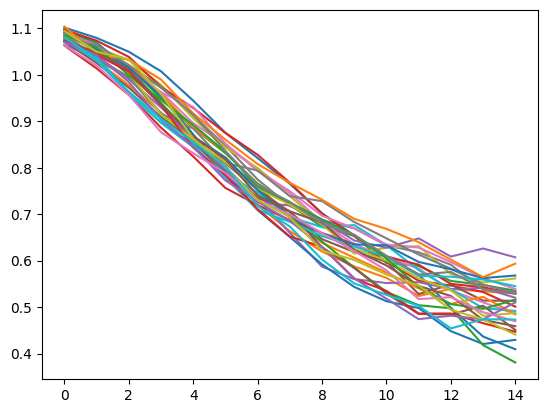

The 95% CI for threshold is 0.23625000000000002 - 0.81375
The chosen threshold: 0.5233333333333333
The 95% CI for TSS is 0.6917592592592592 - 0.8616388888888888

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 42.24 seconds
Max CPU memory used: 8151.50 MB
Max GPU memory used: 387.53 MB


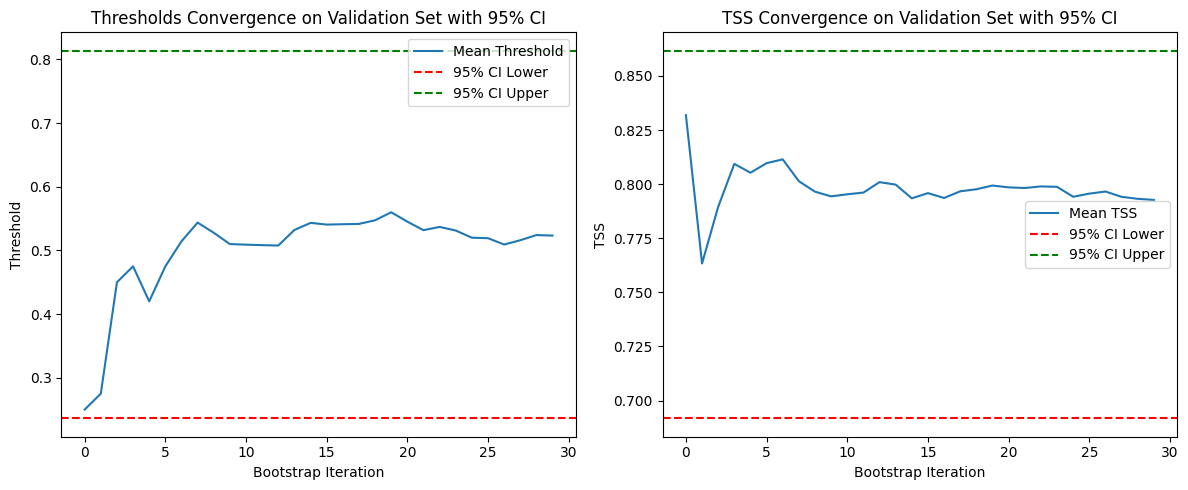

In [41]:
lead12_Task1_opr_nrt = train_lstm()
lead12_Task1_opr_nrt.train(lead12_opr_nrt.inputs_profile, lead12_opr_nrt.labels, "Task1", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [42]:
save_dir = ".\\LSTM_models\\Task1_opr_nrt_models"

for i, model in enumerate(lead12_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead12_Task1_opr_nrt{i}_{np.mean(lead12_Task1_opr_nrt.thresholds)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using all training samples: 284 positives and 620 negatives.
BCE positive-class weight: 2.1831
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9491228972162519
Epoch 2, avg loss: 0.9297374912670681
Epoch 3, avg loss: 0.9113119840621948
Epoch 4, avg loss: 0.8831832749502999
Epoch 5, avg loss: 0.8436919621058873
Epoch 6, avg loss: 0.7911009533064706
Epoch 7, avg loss: 0.7297669393675668
Epoch 8, avg loss: 0.6650601199695042
Epoch 9, avg loss: 0.6189112833568028
Epoch 10, avg loss: 0.5956166897501264
Epoch 11, avg loss: 0.5606680767876762
Epoch 12, avg loss: 0.5404001644679478
Epoch 13, avg loss: 0.5160421133041382
Epoch 14, avg loss: 0.5038955211639404
Epoch 15, avg loss: 0.48721872482981
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.946016822542463
Epoch 2, avg loss: 0.926983083997454
Epoch 3, avg loss: 0.9001507248197284
Epoch 4, avg loss: 0.8564763750348773
Epoch 5, avg loss: 0.7992520332336426
Epoch 6, avg loss: 0.7300142049789429
Epoch 7, avg loss: 0.669648962361472
Epoch 

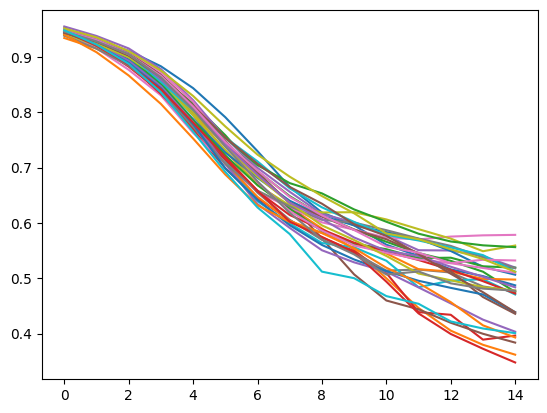

The 95% CI for threshold is 0.15000000000000002 - 0.86375
The chosen threshold: 0.5000000000000001
The 95% CI for TSS is 0.661322463768116 - 0.7875

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 38.17 seconds
Max CPU memory used: 8122.63 MB
Max GPU memory used: 391.53 MB


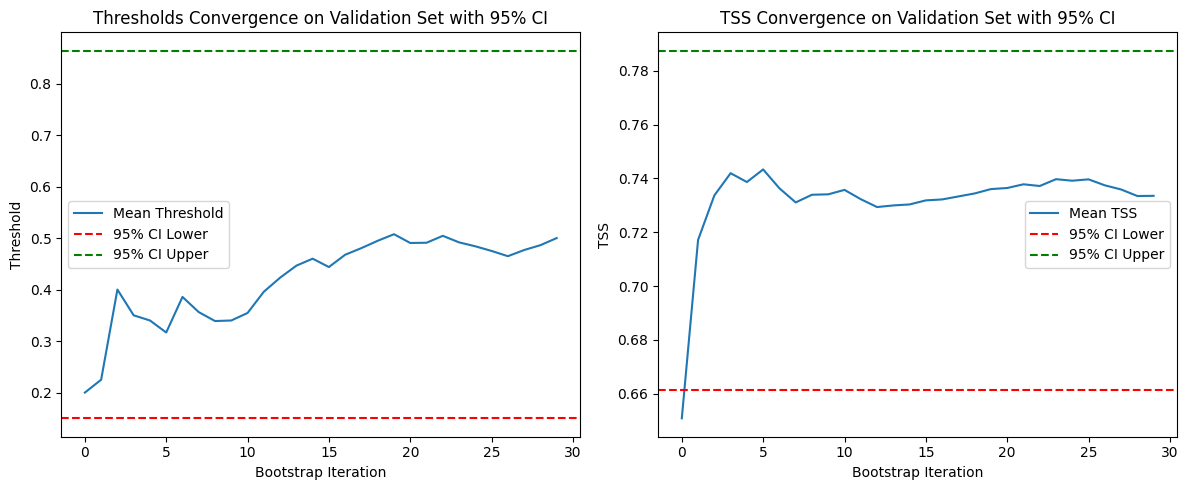

In [43]:
lead24_Task1_sci_nrt = train_lstm()
lead24_Task1_sci_nrt.train(lead24_sci_nrt.inputs_profile, lead24_sci_nrt.labels, "Task1", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [44]:
save_dir = ".\\LSTM_models\\Task1_sci_nrt_models"

for i, model in enumerate(lead24_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead24_Task1_sci_nrt{i}_{np.mean(lead24_Task1_sci_nrt.thresholds)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using all training samples: 219 positives and 852 negatives.
BCE positive-class weight: 3.8904
Bootstrap iteration 1/30
Epoch 1, avg loss: 1.0940106511116028
Epoch 2, avg loss: 1.0702149420976639
Epoch 3, avg loss: 1.0255000293254852
Epoch 4, avg loss: 0.971264660358429
Epoch 5, avg loss: 0.8922322764992714
Epoch 6, avg loss: 0.8233417794108391
Epoch 7, avg loss: 0.7774154171347618
Epoch 8, avg loss: 0.7443517968058586
Epoch 9, avg loss: 0.6941048353910446
Epoch 10, avg loss: 0.6360639669001102
Epoch 11, avg loss: 0.5856600105762482
Epoch 12, avg loss: 0.5395134016871452
Epoch 13, avg loss: 0.48947618156671524
Epoch 14, avg loss: 0.47163447365164757
Epoch 15, avg loss: 0.4609491042792797
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.0908164530992508
Epoch 2, avg loss: 1.071582019329071
Epoch 3, avg loss: 1.0223971828818321
Epoch 4, avg loss: 0.9533658623695374
Epoch 5, avg loss: 0.8690552785992622
Epoch 6, avg loss: 0.79700867831707
Epoch 7, avg loss: 0.7322628051042557
Epo

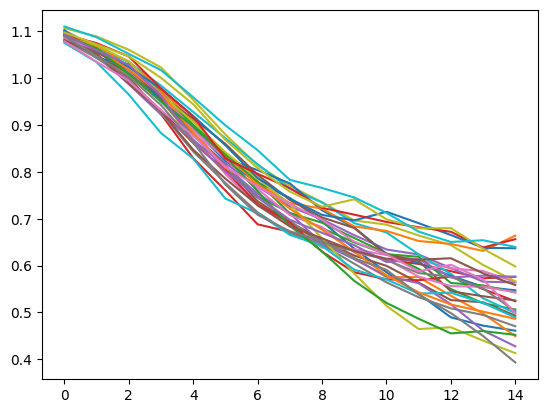

The 95% CI for threshold is 0.2 - 0.75
The chosen threshold: 0.43333333333333335
The 95% CI for TSS is 0.5776041666666666 - 0.8466145833333333

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 46.17 seconds
Max CPU memory used: 8152.11 MB
Max GPU memory used: 393.53 MB


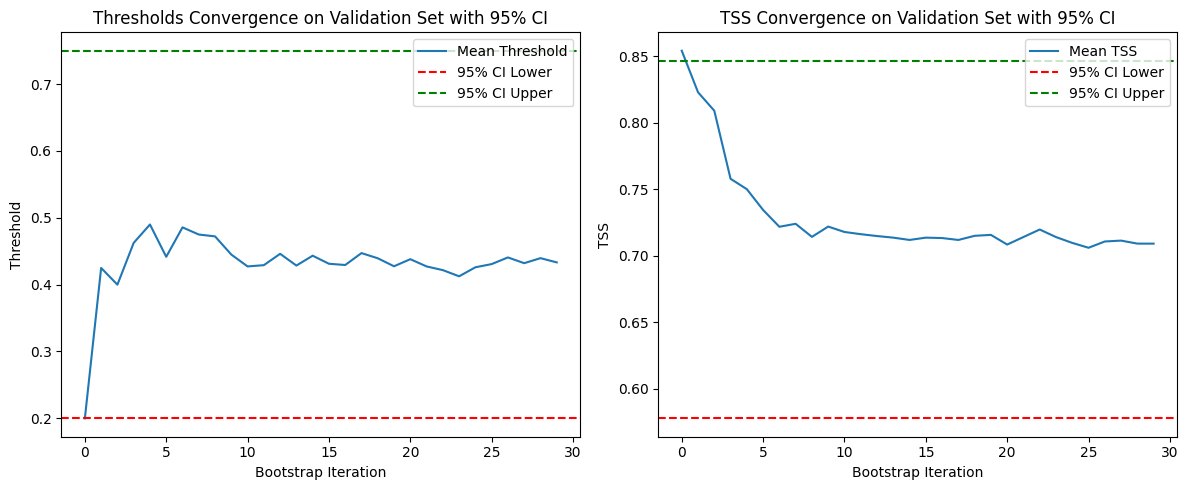

In [45]:
lead24_Task1_opr_nrt = train_lstm()
lead24_Task1_opr_nrt.train(lead24_opr_nrt.inputs_profile, lead24_opr_nrt.labels, "Task1",
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [46]:
save_dir = ".\\LSTM_models\\Task1_opr_nrt_models"

for i, model in enumerate(lead24_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead24_Task1_opr_nrt{i}_{np.mean(lead24_Task1_opr_nrt.thresholds)}.pth")
    torch.save(model.state_dict(), model_path)

## Task2

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 341 positives and 682 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9179807475634983
Epoch 2, avg loss: 0.9170300875391278
Epoch 3, avg loss: 0.9049375057220459
Epoch 4, avg loss: 0.8716425555092948
Epoch 5, avg loss: 0.8571915030479431
Epoch 6, avg loss: 0.8270693591662815
Epoch 7, avg loss: 0.7964014496122088
Epoch 8, avg loss: 0.7715518730027335
Epoch 9, avg loss: 0.7605155025209699
Epoch 10, avg loss: 0.7178553853716169
Epoch 11, avg loss: 0.7562659553119114
Epoch 12, avg loss: 0.722520112991333
Epoch 13, avg loss: 0.7118709342820304
Epoch 14, avg loss: 0.6786742295537677
Epoch 15, avg loss: 0.6662577901567731
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9143613151141575
Epoch 2, avg loss: 0.9081037896020072
Epoch 3, avg loss: 0.8923723357064384
Epoch 4, avg loss: 0.875202476978302
Epoch 5, avg loss: 0.8358850138528007
Epoch 6, a

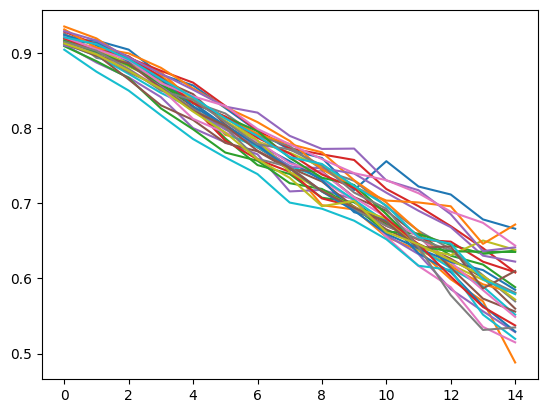

The 95% CI for threshold is 0.23625000000000002 - 0.7274999999999999
The chosen threshold: 0.46499999999999997
The 95% CI for TSS is 0.47546705504218567 - 0.7006126958617919

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 223.27 seconds
Max CPU memory used: 8544.59 MB
Max GPU memory used: 499.53 MB


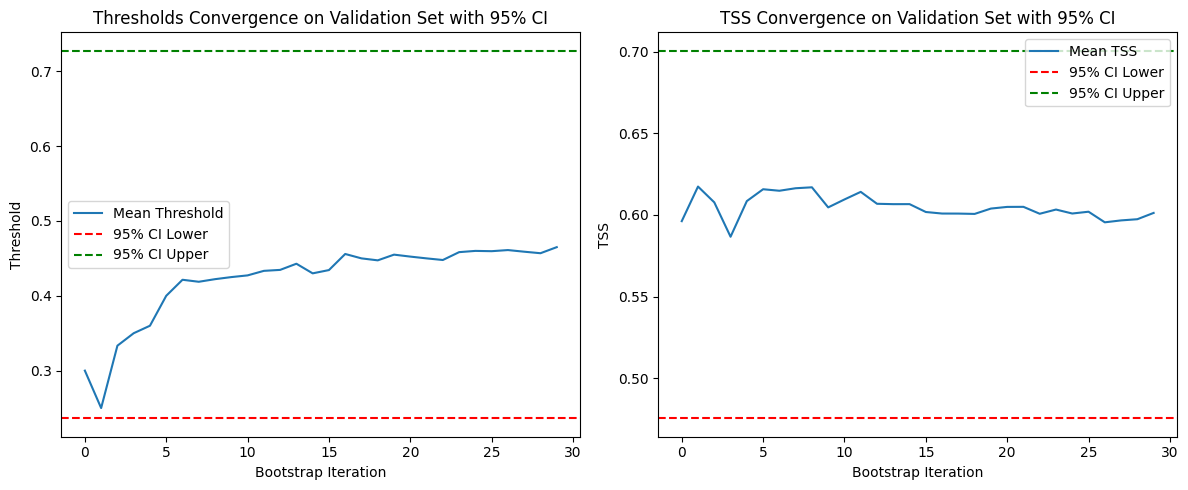

In [56]:
nowcast_Task2_sci_nrt = train_lstm(pos_weight=2.0)
nowcast_Task2_sci_nrt.train(nowcast_sci_nrt.inputs_profile, nowcast_sci_nrt.labels, "Task2", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [48]:
save_dir = ".\\LSTM_models\\Task2_sci_nrt_models"

for i, model in enumerate(nowcast_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"nowcast_Task2_sci_nrt{i}_{np.round(np.mean(nowcast_Task2_sci_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 275 positives and 550 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9210224350293478
Epoch 2, avg loss: 0.8999481995900472
Epoch 3, avg loss: 0.8850739598274231
Epoch 4, avg loss: 0.8552071253458658
Epoch 5, avg loss: 0.8170536557833353
Epoch 6, avg loss: 0.7887104948361715
Epoch 7, avg loss: 0.75666477282842
Epoch 8, avg loss: 0.7351670563220978
Epoch 9, avg loss: 0.7053350309530894
Epoch 10, avg loss: 0.680556853612264
Epoch 11, avg loss: 0.6467392345269521
Epoch 12, avg loss: 0.6468391319115957
Epoch 13, avg loss: 0.6073281069596609
Epoch 14, avg loss: 0.5836498637994131
Epoch 15, avg loss: 0.5590193271636963
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9238887925942739
Epoch 2, avg loss: 0.915171225865682
Epoch 3, avg loss: 0.908926397562027
Epoch 4, avg loss: 0.8934078613917033
Epoch 5, avg loss: 0.8683880269527435
Epoch 6, avg 

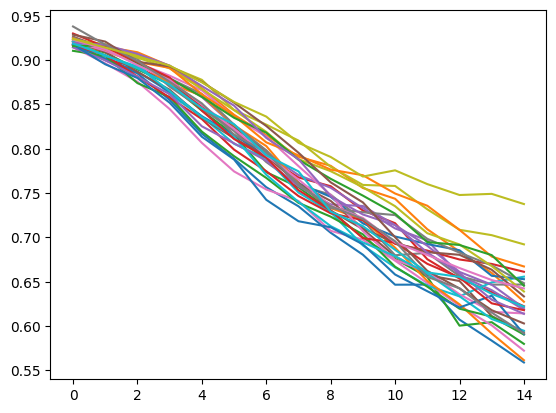

The 95% CI for threshold is 0.33625000000000005 - 0.71375
The chosen threshold: 0.48500000000000004
The 95% CI for TSS is 0.5859084799608993 - 0.7497892228739003

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 35.46 seconds
Max CPU memory used: 8302.88 MB
Max GPU memory used: 489.53 MB


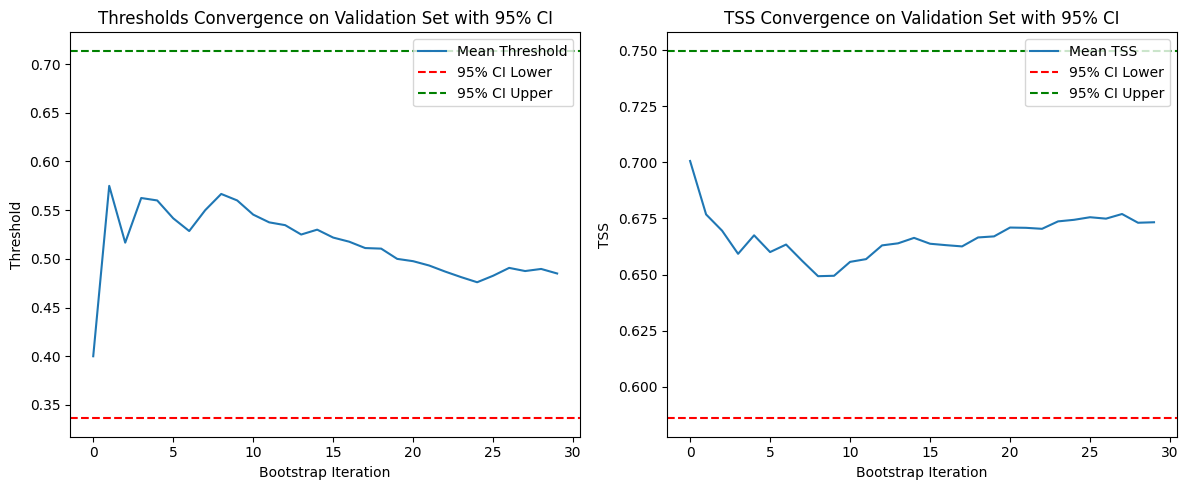

In [49]:
nowcast_Task2_opr_nrt = train_lstm(pos_weight=2.0)
nowcast_Task2_opr_nrt.train(nowcast_opr_nrt.inputs_profile, nowcast_opr_nrt.labels, "Task2", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [50]:
save_dir = ".\\LSTM_models\\Task2_opr_nrt_models"

for i, model in enumerate(nowcast_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"nowcast_Task2_opr_nrt{i}_{np.round(np.mean(nowcast_Task2_opr_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 320 positives and 640 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9212444084031242
Epoch 2, avg loss: 0.9033608947481427
Epoch 3, avg loss: 0.8867352179118565
Epoch 4, avg loss: 0.8547220655850002
Epoch 5, avg loss: 0.826873140675681
Epoch 6, avg loss: 0.7998779160635812
Epoch 7, avg loss: 0.7798493674823216
Epoch 8, avg loss: 0.7503728355680194
Epoch 9, avg loss: 0.7260479160717556
Epoch 10, avg loss: 0.7076050383704049
Epoch 11, avg loss: 0.6951728633471898
Epoch 12, avg loss: 0.6752353055136544
Epoch 13, avg loss: 0.6541881561279297
Epoch 14, avg loss: 0.6188696282250541
Epoch 15, avg loss: 0.6148705397333417
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9201210226331439
Epoch 2, avg loss: 0.9071673154830933
Epoch 3, avg loss: 0.8892096962247577
Epoch 4, avg loss: 0.873038683618818
Epoch 5, avg loss: 0.8393354756491525
Epoch 6, a

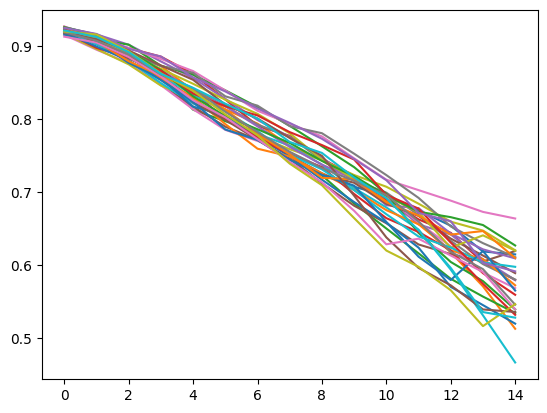

The 95% CI for threshold is 0.28625000000000006 - 0.75
The chosen threshold: 0.5416666666666666
The 95% CI for TSS is 0.5806986853265478 - 0.7727841391009329

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 172.11 seconds
Max CPU memory used: 8313.03 MB
Max GPU memory used: 493.53 MB


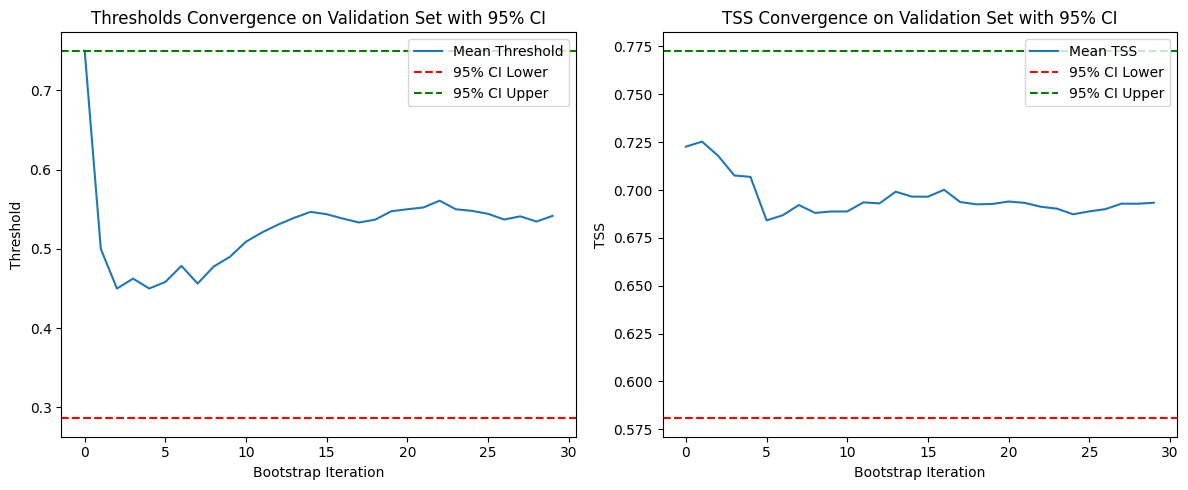

In [51]:
lead6_Task2_sci_nrt = train_lstm(pos_weight=2.0)
lead6_Task2_sci_nrt.train(lead6_sci_nrt.inputs_profile, lead6_sci_nrt.labels, "Task2", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [52]:
save_dir = ".\\LSTM_models\\Task2_sci_nrt_models"

for i, model in enumerate(lead6_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead6_Task2_sci_nrt{i}_{np.round(np.mean(lead6_Task2_sci_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 258 positives and 516 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9235674341519674
Epoch 2, avg loss: 0.9046362539132436
Epoch 3, avg loss: 0.8879527946313223
Epoch 4, avg loss: 0.8621788422266642
Epoch 5, avg loss: 0.8249058226744334
Epoch 6, avg loss: 0.7871402402718862
Epoch 7, avg loss: 0.7576394081115723
Epoch 8, avg loss: 0.720667282740275
Epoch 9, avg loss: 0.6940863331158956
Epoch 10, avg loss: 0.6621853311856588
Epoch 11, avg loss: 0.6312901874383291
Epoch 12, avg loss: 0.6028182407220205
Epoch 13, avg loss: 0.5944061179955801
Epoch 14, avg loss: 0.5742053985595703
Epoch 15, avg loss: 0.5739489197731018
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9228436251481374
Epoch 2, avg loss: 0.9105635484059652
Epoch 3, avg loss: 0.897680809100469
Epoch 4, avg loss: 0.8796762426694235
Epoch 5, avg loss: 0.8599869708220164
Epoch 6, a

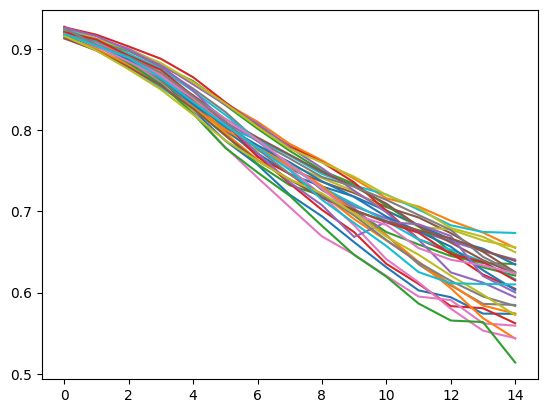

The 95% CI for threshold is 0.23625000000000002 - 0.8
The chosen threshold: 0.5233333333333333
The 95% CI for TSS is 0.4323635057471265 - 0.610824843260188

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 193.64 seconds
Max CPU memory used: 8530.39 MB
Max GPU memory used: 499.53 MB


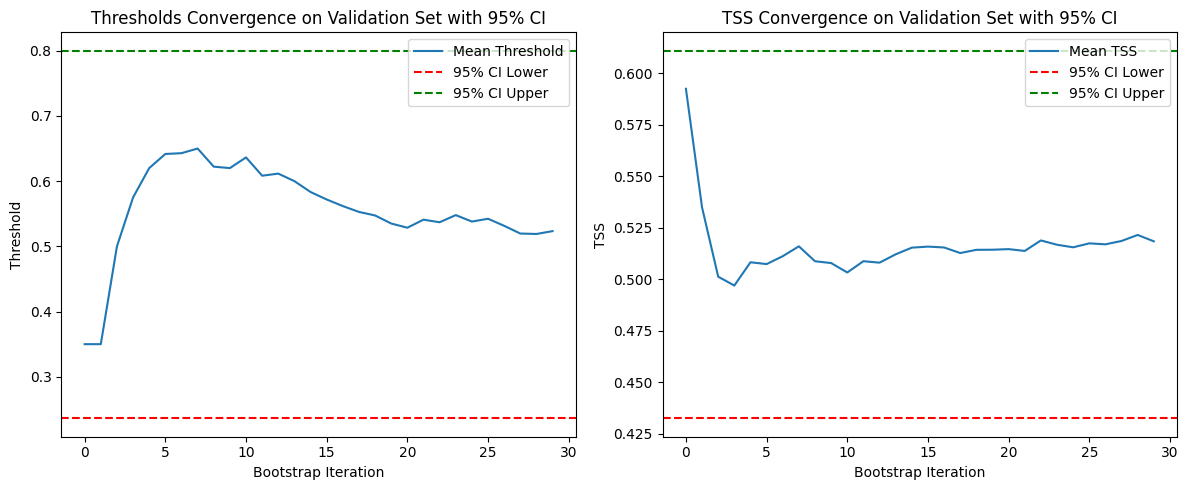

In [57]:
lead6_Task2_opr_nrt = train_lstm(pos_weight=2.0)
lead6_Task2_opr_nrt.train(lead6_opr_nrt.inputs_profile, lead6_opr_nrt.labels, "Task2", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [58]:
save_dir = ".\\LSTM_models\\Task2_opr_nrt_models"

for i, model in enumerate(lead6_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead6_Task2_opr_nrt{i}_{np.round(np.mean(lead6_Task2_opr_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 302 positives and 604 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.919027967112405
Epoch 2, avg loss: 0.9011680824416024
Epoch 3, avg loss: 0.8718634758676801
Epoch 4, avg loss: 0.8289393186569214
Epoch 5, avg loss: 0.7953716346195766
Epoch 6, avg loss: 0.7680772713252476
Epoch 7, avg loss: 0.7436010496956962
Epoch 8, avg loss: 0.7186848265784127
Epoch 9, avg loss: 0.6948129108973912
Epoch 10, avg loss: 0.6675068736076355
Epoch 11, avg loss: 0.6351017951965332
Epoch 12, avg loss: 0.6057598761149815
Epoch 13, avg loss: 0.5739941086087909
Epoch 14, avg loss: 0.5375033063547952
Epoch 15, avg loss: 0.5062666450228009
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.919895989554269
Epoch 2, avg loss: 0.9077119656971523
Epoch 3, avg loss: 0.8893216933522906
Epoch 4, avg loss: 0.8634398579597473
Epoch 5, avg loss: 0.8307936617306301
Epoch 6, a

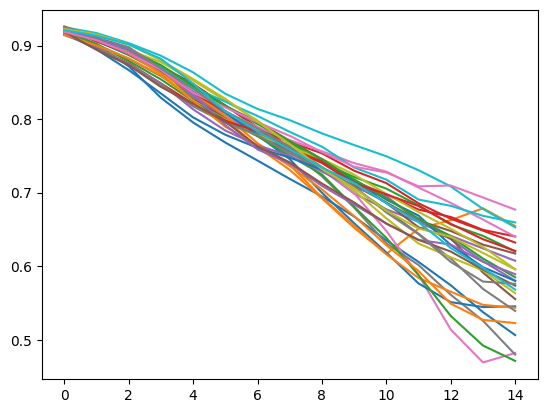

The 95% CI for threshold is 0.23625000000000002 - 0.7000000000000001
The chosen threshold: 0.44499999999999995
The 95% CI for TSS is 0.4279755092698558 - 0.7363670176241703

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 228.69 seconds
Max CPU memory used: 7829.48 MB
Max GPU memory used: 501.53 MB


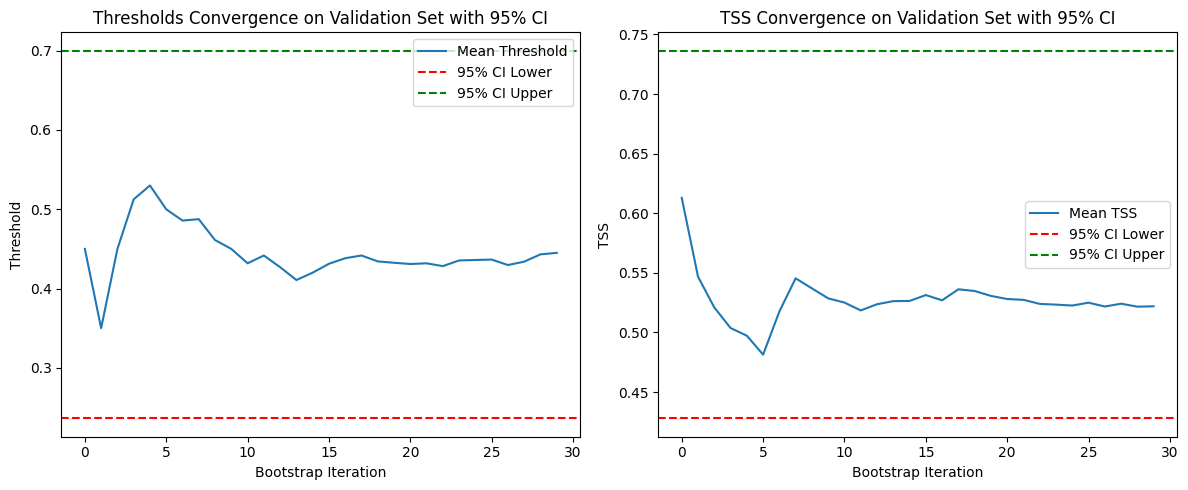

In [59]:
lead12_Task2_sci_nrt = train_lstm(pos_weight=2.0)
lead12_Task2_sci_nrt.train(lead12_sci_nrt.inputs_profile, lead12_sci_nrt.labels, "Task2", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [60]:
save_dir = ".\\LSTM_models\\Task2_sci_nrt_models"

for i, model in enumerate(lead12_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead12_Task2_sci_nrt{i}_{np.round(np.mean(lead12_Task2_sci_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 239 positives and 478 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9310800313949585
Epoch 2, avg loss: 0.9178143382072449
Epoch 3, avg loss: 0.9117843627929687
Epoch 4, avg loss: 0.894826066493988
Epoch 5, avg loss: 0.8751166462898254
Epoch 6, avg loss: 0.8544091820716858
Epoch 7, avg loss: 0.8135681033134461
Epoch 8, avg loss: 0.7809984922409058
Epoch 9, avg loss: 0.7408550381660461
Epoch 10, avg loss: 0.7373978137969971
Epoch 11, avg loss: 0.710970664024353
Epoch 12, avg loss: 0.6931738376617431
Epoch 13, avg loss: 0.6782591462135314
Epoch 14, avg loss: 0.6439272403717041
Epoch 15, avg loss: 0.6418633460998535
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9093418002128602
Epoch 2, avg loss: 0.9065099358558655
Epoch 3, avg loss: 0.8915966749191284
Epoch 4, avg loss: 0.8793952345848084
Epoch 5, avg loss: 0.858620023727417
Epoch 6, av

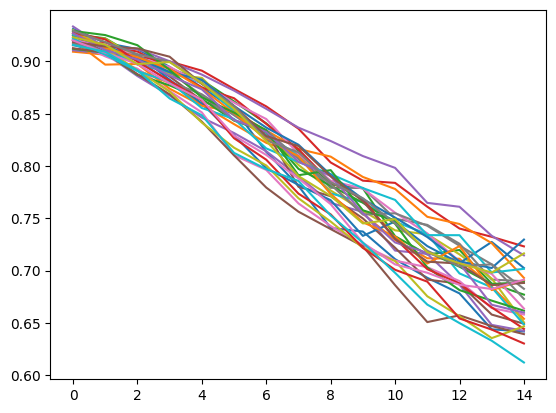

The 95% CI for threshold is 0.33625000000000005 - 0.75
The chosen threshold: 0.5399999999999999
The 95% CI for TSS is 0.4493214588634436 - 0.6096692111959288

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 164.74 seconds
Max CPU memory used: 7128.56 MB
Max GPU memory used: 505.53 MB


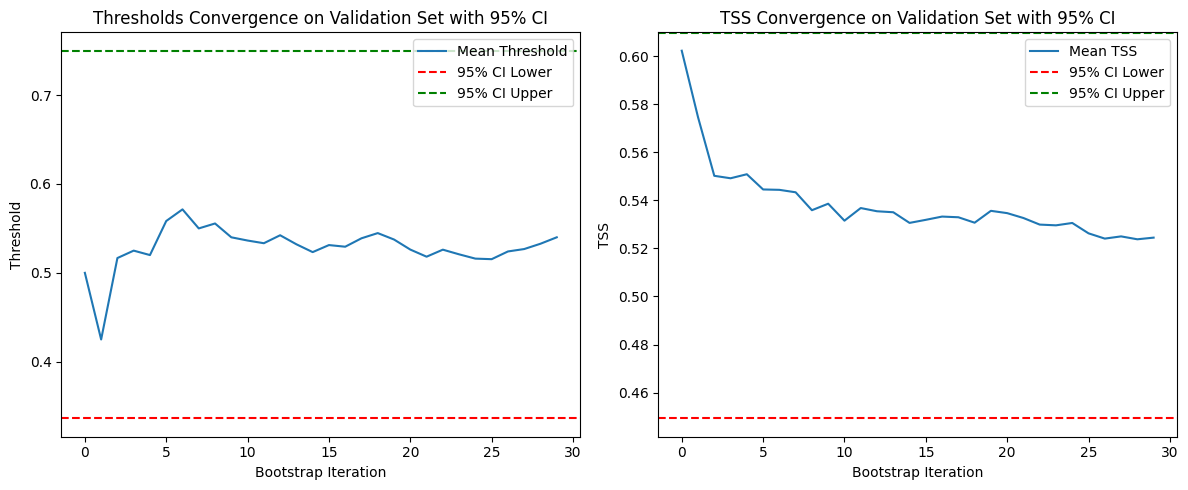

In [61]:
lead12_Task2_opr_nrt = train_lstm(pos_weight=2.0)
lead12_Task2_opr_nrt.train(lead12_opr_nrt.inputs_profile, lead12_opr_nrt.labels, "Task2", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [62]:
save_dir = ".\\LSTM_models\\Task2_opr_nrt_models"

for i, model in enumerate(lead12_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead12_Task2_opr_nrt{i}_{np.round(np.mean(lead12_Task2_opr_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 284 positives and 568 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9244502087434133
Epoch 2, avg loss: 0.9100427031517029
Epoch 3, avg loss: 0.8950135807196299
Epoch 4, avg loss: 0.8742039601008097
Epoch 5, avg loss: 0.8533031741778055
Epoch 6, avg loss: 0.8147161801656088
Epoch 7, avg loss: 0.7949365973472595
Epoch 8, avg loss: 0.7714974780877432
Epoch 9, avg loss: 0.7408098677794138
Epoch 10, avg loss: 0.7248564461867014
Epoch 11, avg loss: 0.69046883781751
Epoch 12, avg loss: 0.6604882478713989
Epoch 13, avg loss: 0.632137397925059
Epoch 14, avg loss: 0.607339878877004
Epoch 15, avg loss: 0.6048374871412913
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.918698251247406
Epoch 2, avg loss: 0.8971915145715078
Epoch 3, avg loss: 0.8943436642487844
Epoch 4, avg loss: 0.8521714508533478
Epoch 5, avg loss: 0.8423210382461548
Epoch 6, avg 

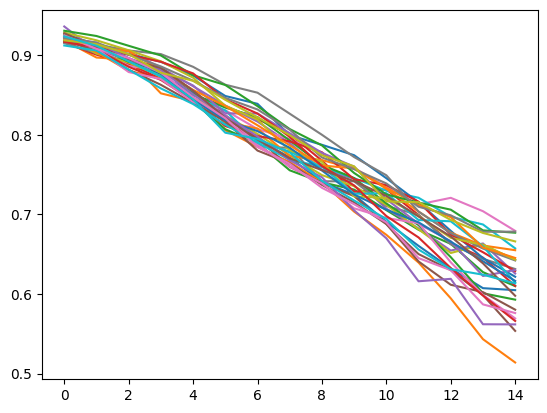

The 95% CI for threshold is 0.28625000000000006 - 0.71375
The chosen threshold: 0.5400000000000001
The 95% CI for TSS is 0.45569648279352226 - 0.6392712550607287

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 199.57 seconds
Max CPU memory used: 7127.52 MB
Max GPU memory used: 509.53 MB


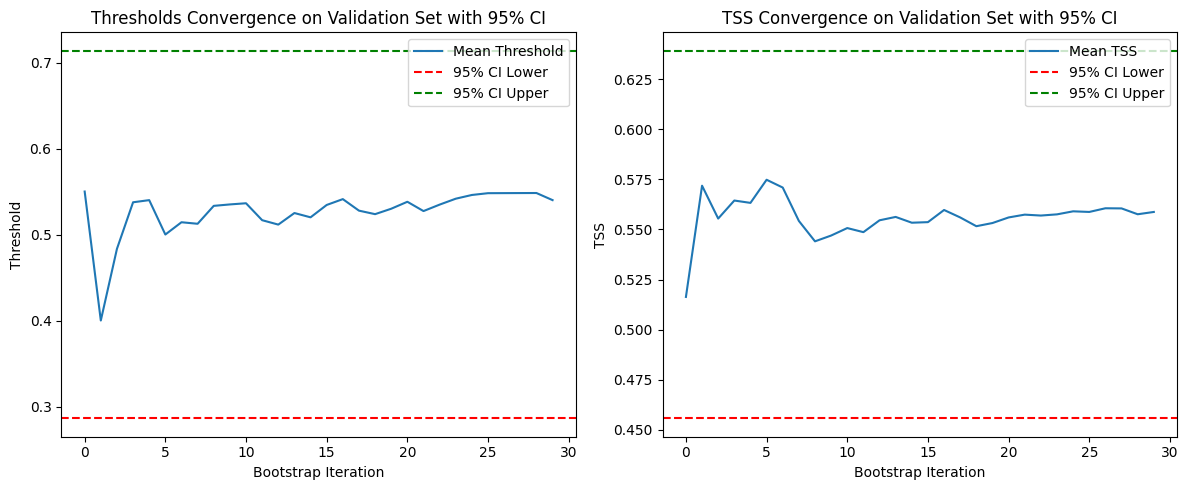

In [63]:
lead24_Task2_sci_nrt = train_lstm(pos_weight=2.0)
lead24_Task2_sci_nrt.train(lead24_sci_nrt.inputs_profile, lead24_sci_nrt.labels, "Task2", 
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [64]:
save_dir = ".\\LSTM_models\\Task2_sci_nrt_models"

for i, model in enumerate(lead24_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead24_Task2_sci_nrt{i}_{np.round(np.mean(lead24_Task2_sci_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

get samples
Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 219 positives and 438 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.9246604681015015
Epoch 2, avg loss: 0.9186246633529663
Epoch 3, avg loss: 0.9101647138595581
Epoch 4, avg loss: 0.9002927899360657
Epoch 5, avg loss: 0.8898663997650147
Epoch 6, avg loss: 0.876598572731018
Epoch 7, avg loss: 0.857188081741333
Epoch 8, avg loss: 0.8373238801956177
Epoch 9, avg loss: 0.8140100359916687
Epoch 10, avg loss: 0.8023141980171203
Epoch 11, avg loss: 0.778558075428009
Epoch 12, avg loss: 0.7698718786239624
Epoch 13, avg loss: 0.7482533812522888
Epoch 14, avg loss: 0.731120252609253
Epoch 15, avg loss: 0.725459349155426
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.9177940249443054
Epoch 2, avg loss: 0.9077642560005188
Epoch 3, avg loss: 0.8989242315292358
Epoch 4, avg loss: 0.8848512411117554
Epoch 5, avg loss: 0.8629671335220337
Epoch 6, avg 

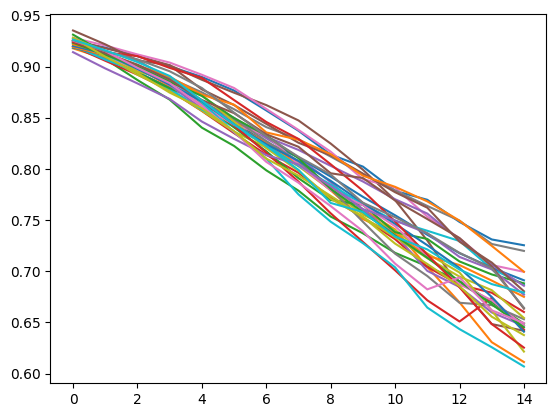

The 95% CI for threshold is 0.30000000000000004 - 0.7000000000000001
The chosen threshold: 0.49500000000000005
The 95% CI for TSS is 0.43854166666666666 - 0.6811642156862745

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 167.48 seconds
Max CPU memory used: 3584.60 MB
Max GPU memory used: 511.53 MB


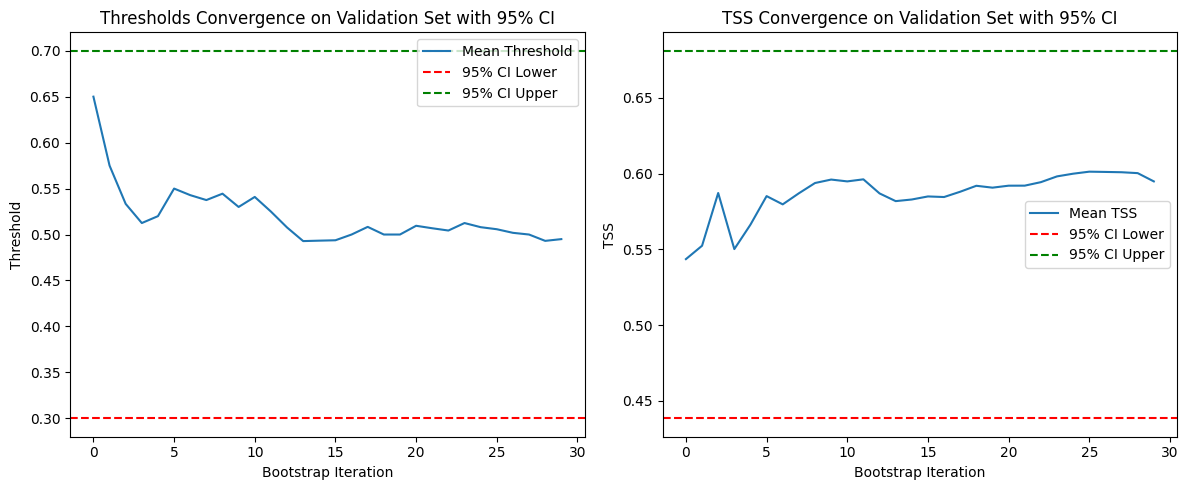

In [65]:
lead24_Task2_opr_nrt = train_lstm(pos_weight=2.0)
lead24_Task2_opr_nrt.train(lead24_opr_nrt.inputs_profile, lead24_opr_nrt.labels, "Task2",
                            pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'), n_epoch=15)

In [66]:
save_dir = ".\\LSTM_models\\Task2_opr_nrt_models"

for i, model in enumerate(lead24_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead24_Task2_opr_nrt{i}_{np.round(np.mean(lead24_Task2_opr_nrt.thresholds), 2)}.pth")
    torch.save(model.state_dict(), model_path)

## Logistic Regression

### Task1

In [67]:
from New_logistic import *
import joblib

Using all training samples: 341 positives and 730 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 2/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 3/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 4/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 5/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 6/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 7/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 8/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 9/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 10/30
Bootstrap sample: 341 positives, 730 negatives; ratio=2.1408
Bootstrap iteration 11/30
Bootstrap sample: 341 positives, 730 negatives; rati

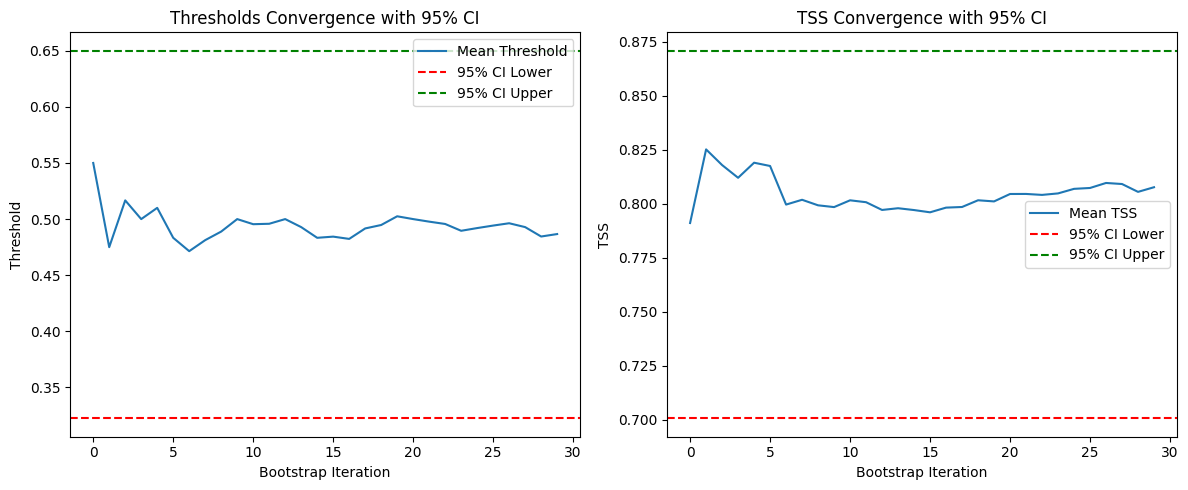

In [68]:
logistic_nowcast_Task1_sci_nrt = train_logistic()
logistic_nowcast_Task1_sci_nrt.train_logistic(nowcast_sci_nrt.inputs_profile, nowcast_sci_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [69]:
save_dir = ".\\Logreg_models\\Task1_sci_nrt_models"

for i, model in enumerate(logistic_nowcast_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_nowcast_Task1_sci_nrt{i}_{np.round(np.mean(logistic_nowcast_Task1_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using all training samples: 275 positives and 937 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 2/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 3/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 4/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 5/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 6/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 7/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 8/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 9/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 10/30
Bootstrap sample: 275 positives, 937 negatives; ratio=3.4073
Bootstrap iteration 11/30
Bootstrap sample: 275 positives, 937 negatives; rati

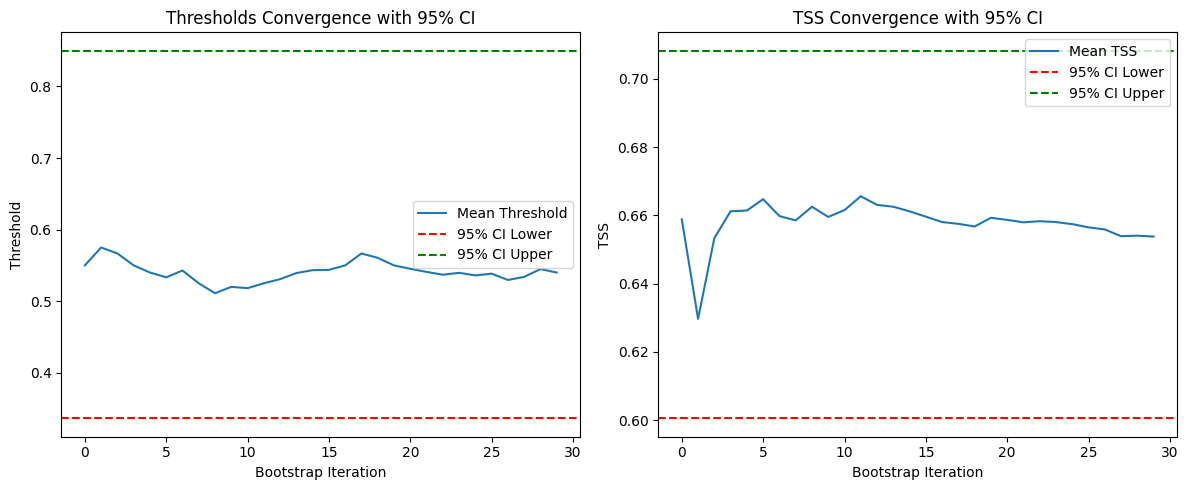

In [70]:
logistic_nowcast_Task1_opr_nrt = train_logistic()
logistic_nowcast_Task1_opr_nrt.train_logistic(nowcast_opr_nrt.inputs_profile, nowcast_opr_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [71]:
save_dir = ".\\Logreg_models\\Task1_opr_nrt_models"

for i, model in enumerate(logistic_nowcast_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_nowcast_Task1_opr_nrt{i}_{np.round(np.mean(logistic_nowcast_Task1_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using all training samples: 320 positives and 716 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 2/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 3/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 4/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 5/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 6/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 7/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 8/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 9/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 10/30
Bootstrap sample: 320 positives, 716 negatives; ratio=2.2375
Bootstrap iteration 11/30
Bootstrap sample: 320 positives, 716 negatives; rati

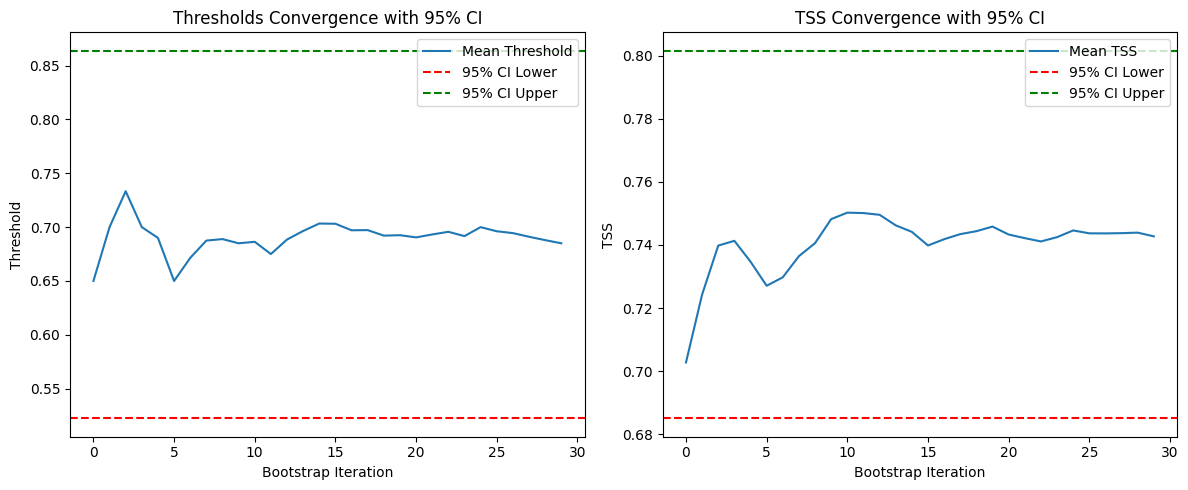

In [72]:
logistic_lead6_Task1_sci_nrt = train_logistic()
logistic_lead6_Task1_sci_nrt.train_logistic(lead6_sci_nrt.inputs_profile, lead6_sci_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [73]:
save_dir = ".\\Logreg_models\\Task1_sci_nrt_models"

for i, model in enumerate(logistic_lead6_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead6_Task1_sci_nrt{i}_{np.round(np.mean(logistic_lead6_Task1_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using all training samples: 258 positives and 922 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 2/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 3/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 4/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 5/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 6/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 7/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 8/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 9/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 10/30
Bootstrap sample: 258 positives, 922 negatives; ratio=3.5736
Bootstrap iteration 11/30
Bootstrap sample: 258 positives, 922 negatives; rati

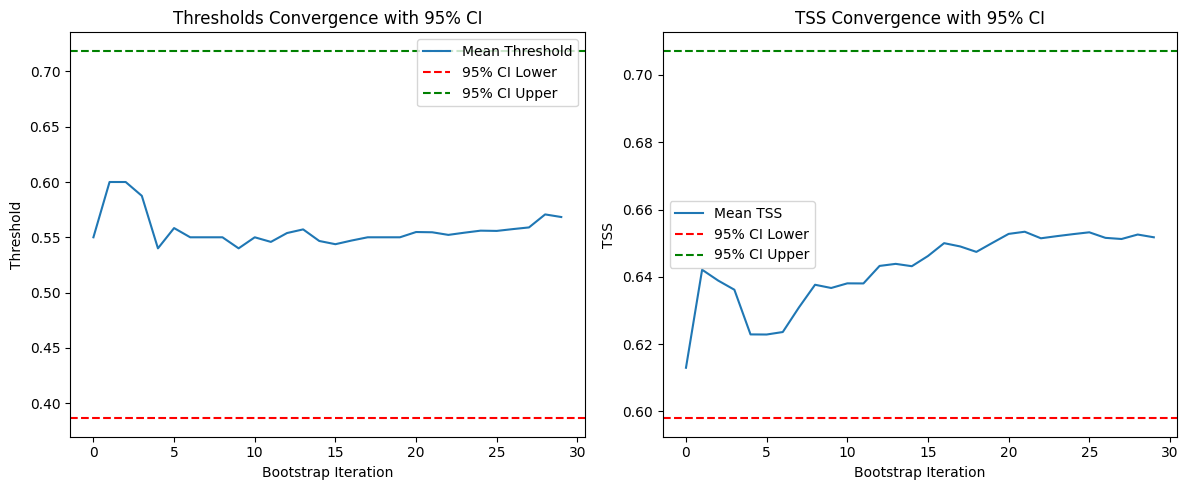

In [74]:
logistic_lead6_Task1_opr_nrt = train_logistic()
logistic_lead6_Task1_opr_nrt.train_logistic(lead6_opr_nrt.inputs_profile, lead6_opr_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [75]:
save_dir = ".\\Logreg_models\\Task1_opr_nrt_models"

for i, model in enumerate(logistic_lead6_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead6_Task1_opr_nrt{i}_{np.round(np.mean(logistic_lead6_Task1_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using all training samples: 302 positives and 679 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 2/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 3/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 4/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 5/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 6/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 7/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 8/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 9/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 10/30
Bootstrap sample: 302 positives, 679 negatives; ratio=2.2483
Bootstrap iteration 11/30
Bootstrap sample: 302 positives, 679 negatives; rati

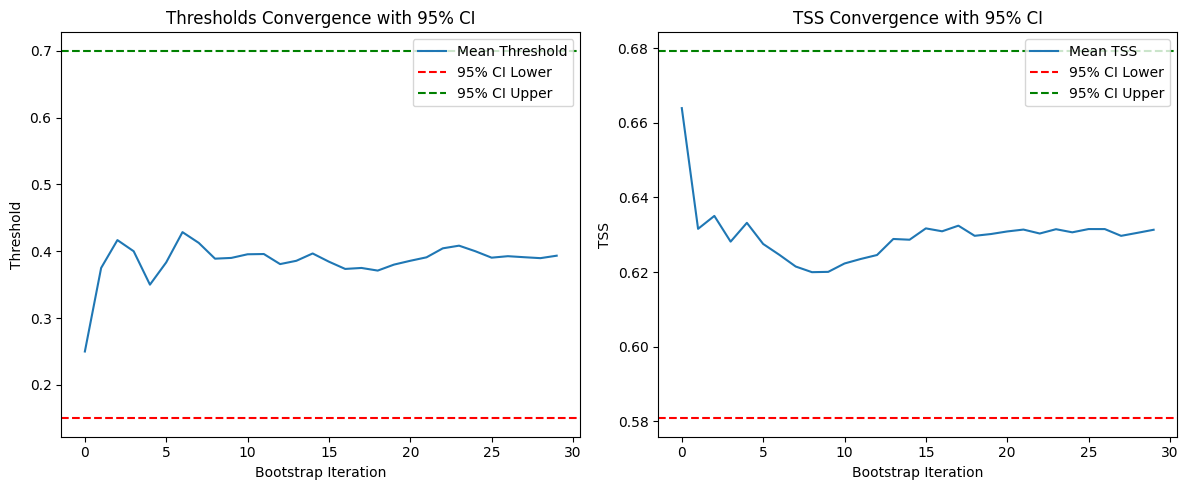

In [76]:
logistic_lead12_Task1_sci_nrt = train_logistic()
logistic_lead12_Task1_sci_nrt.train_logistic(lead12_sci_nrt.inputs_profile, lead12_sci_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [77]:
save_dir = ".\\Logreg_models\\Task1_sci_nrt_models"

for i, model in enumerate(logistic_lead12_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead12_Task1_sci_nrt{i}_{np.round(np.mean(logistic_lead12_Task1_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using all training samples: 239 positives and 898 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 2/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 3/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 4/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 5/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 6/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 7/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 8/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 9/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 10/30
Bootstrap sample: 239 positives, 898 negatives; ratio=3.7573
Bootstrap iteration 11/30
Bootstrap sample: 239 positives, 898 negatives; rati

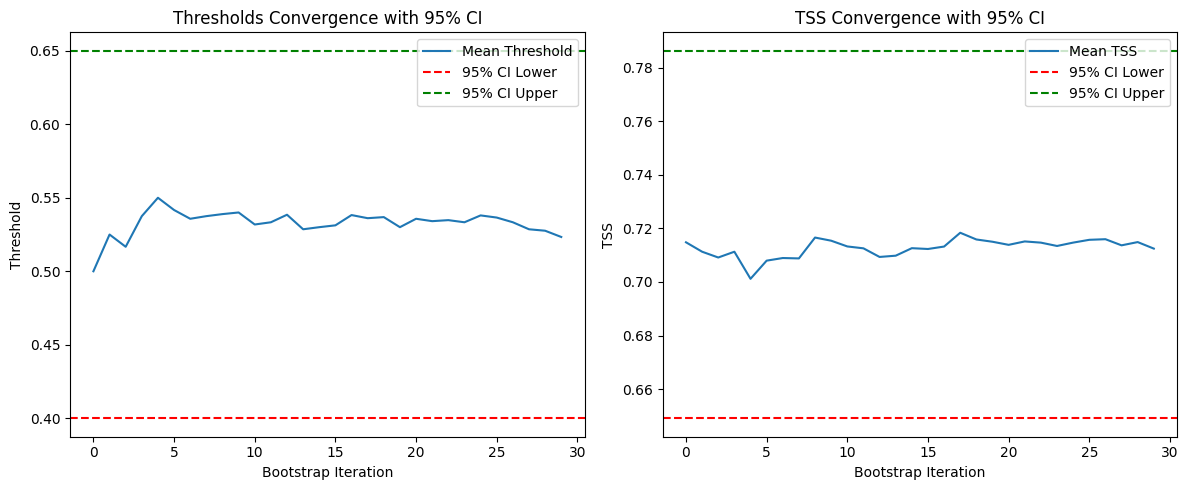

In [78]:
logistic_lead12_Task1_opr_nrt = train_logistic()
logistic_lead12_Task1_opr_nrt.train_logistic(lead12_opr_nrt.inputs_profile, lead12_opr_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [79]:
save_dir = ".\\Logreg_models\\Task1_opr_nrt_models"

for i, model in enumerate(logistic_lead12_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead12_Task1_opr_nrt{i}_{np.round(np.mean(logistic_lead12_Task1_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using all training samples: 284 positives and 620 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 2/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 3/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 4/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 5/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 6/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 7/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 8/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 9/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 10/30
Bootstrap sample: 284 positives, 620 negatives; ratio=2.1831
Bootstrap iteration 11/30
Bootstrap sample: 284 positives, 620 negatives; rati

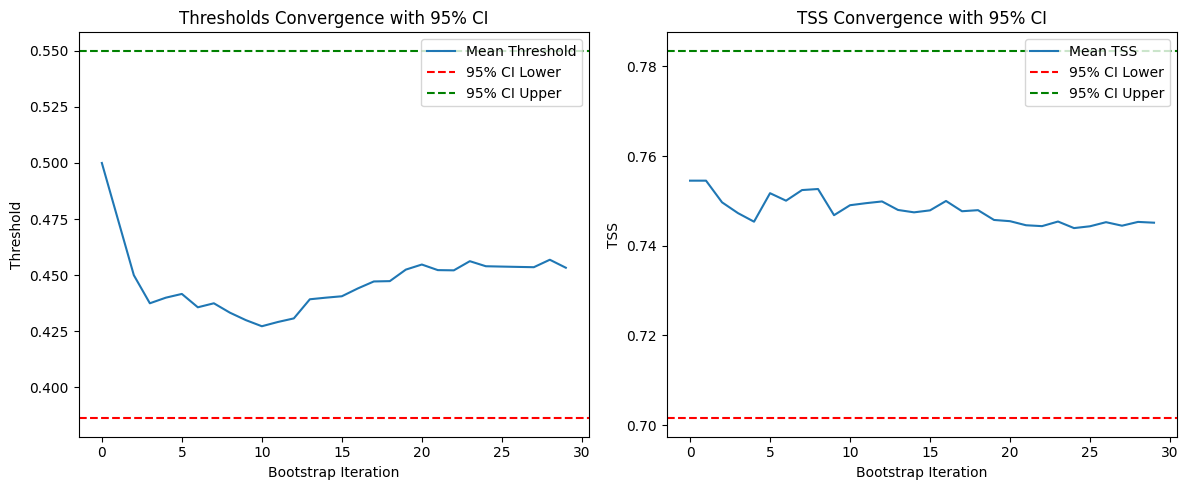

In [80]:
logistic_lead24_Task1_sci_nrt = train_logistic()
logistic_lead24_Task1_sci_nrt.train_logistic(lead24_sci_nrt.inputs_profile, lead24_sci_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [81]:
save_dir = ".\\Logreg_models\\Task1_sci_nrt_models"

for i, model in enumerate(logistic_lead24_Task1_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead24_Task1_sci_nrt{i}_{np.round(np.mean(logistic_lead24_Task1_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using all training samples: 219 positives and 852 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 2/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 3/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 4/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 5/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 6/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 7/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 8/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 9/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 10/30
Bootstrap sample: 219 positives, 852 negatives; ratio=3.8904
Bootstrap iteration 11/30
Bootstrap sample: 219 positives, 852 negatives; rati

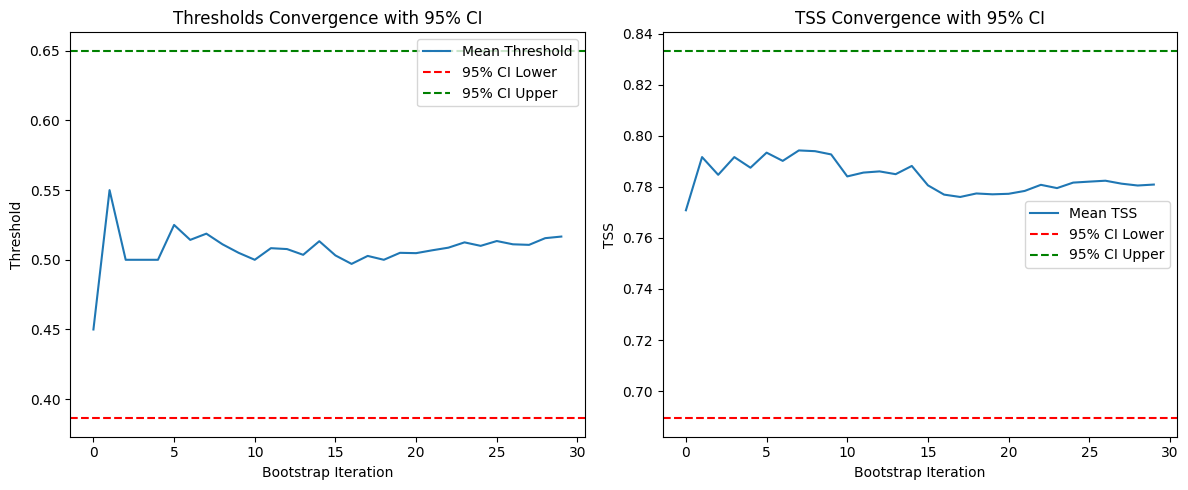

In [82]:
logistic_lead24_Task1_opr_nrt = train_logistic()
logistic_lead24_Task1_opr_nrt.train_logistic(lead24_opr_nrt.inputs_profile, lead24_opr_nrt.labels, "Task1", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [83]:
save_dir = ".\\Logreg_models\\Task1_opr_nrt_models"

for i, model in enumerate(logistic_lead24_Task1_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead24_Task1_opr_nrt{i}_{np.round(np.mean(logistic_lead24_Task1_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

### Task2

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 341 positives and 682 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 341 positives, 682 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

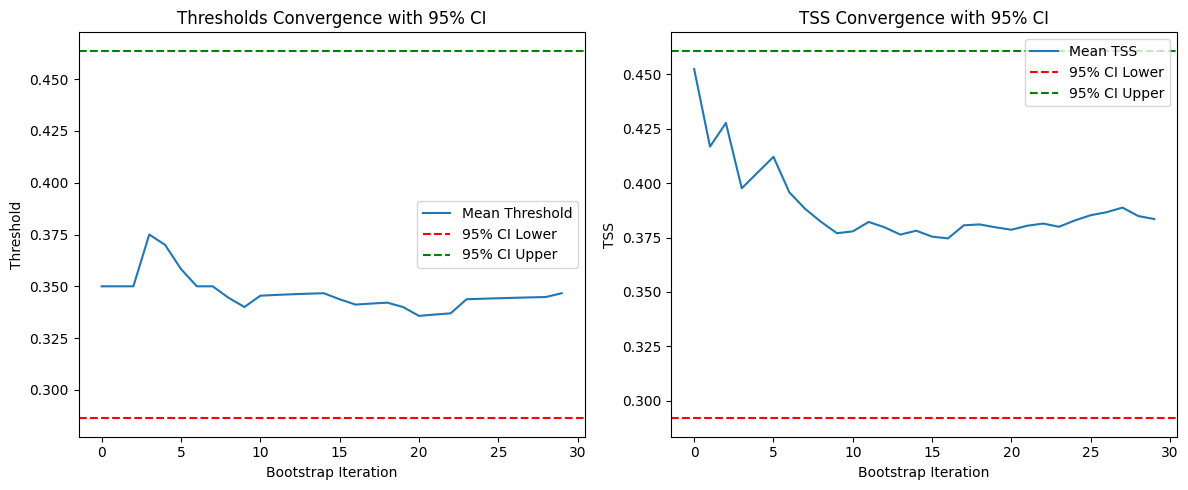

In [84]:
logistic_nowcast_Task2_sci_nrt = train_logistic(pos_weight=2.0)
logistic_nowcast_Task2_sci_nrt.train_logistic(nowcast_sci_nrt.inputs_profile, nowcast_sci_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [85]:
save_dir = ".\\Logreg_models\\Task2_sci_nrt_models"

for i, model in enumerate(logistic_nowcast_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_nowcast_Task2_sci_nrt{i}_{np.round(np.mean(logistic_nowcast_Task2_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 275 positives and 550 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 275 positives, 550 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

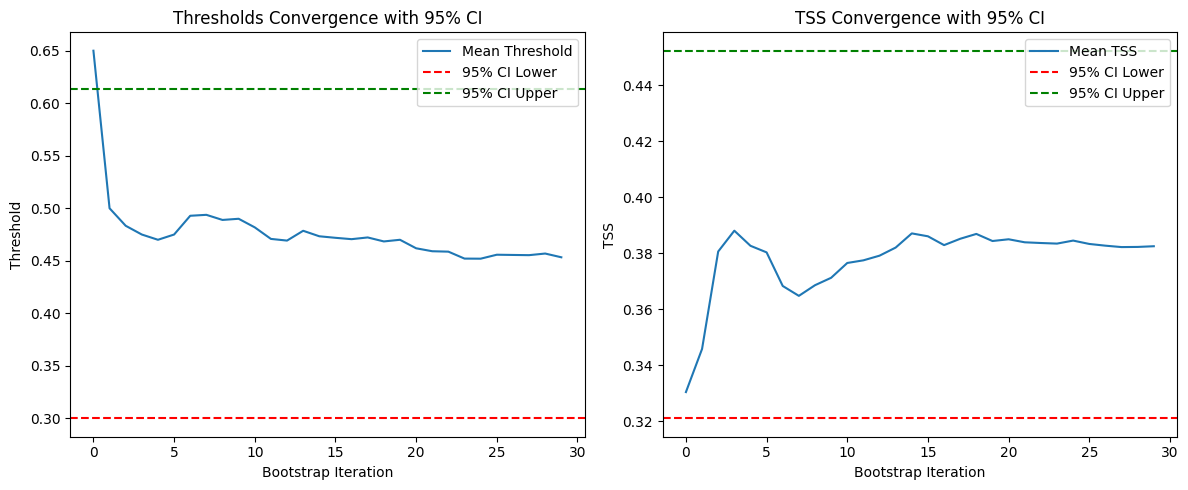

In [86]:
logistic_nowcast_Task2_opr_nrt = train_logistic(pos_weight=2.0)
logistic_nowcast_Task2_opr_nrt.train_logistic(nowcast_opr_nrt.inputs_profile, nowcast_opr_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [87]:
save_dir = ".\\Logreg_models\\Task2_opr_nrt_models"

for i, model in enumerate(logistic_nowcast_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_nowcast_Task2_opr_nrt{i}_{np.round(np.mean(logistic_nowcast_Task2_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 320 positives and 640 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 320 positives, 640 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

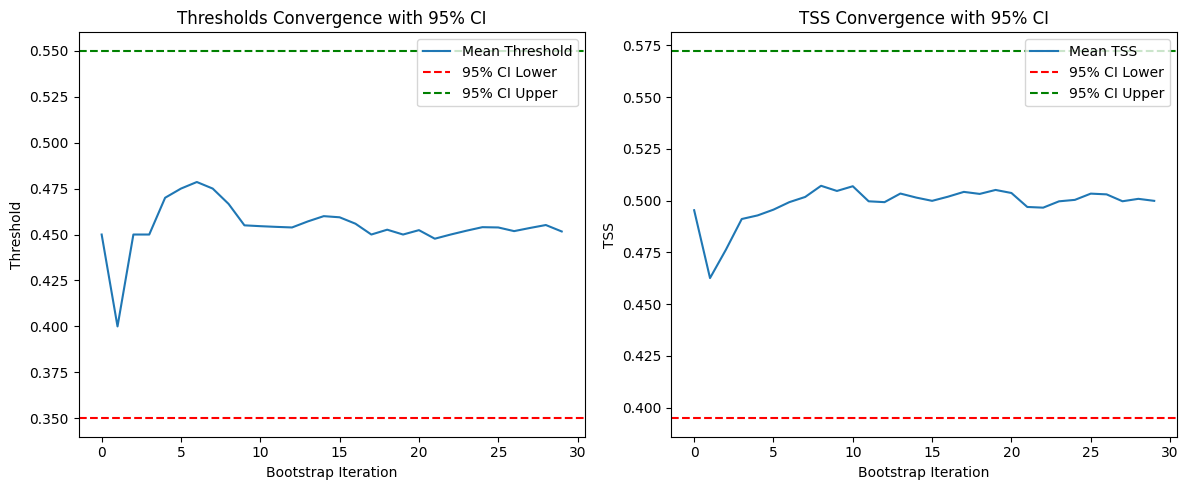

In [88]:
logistic_lead6_Task2_sci_nrt = train_logistic(pos_weight=2.0)
logistic_lead6_Task2_sci_nrt.train_logistic(lead6_sci_nrt.inputs_profile, lead6_sci_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [89]:
save_dir = ".\\Logreg_models\\Task2_sci_nrt_models"

for i, model in enumerate(logistic_lead6_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead6_Task2_sci_nrt{i}_{np.round(np.mean(logistic_lead6_Task2_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 258 positives and 516 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 258 positives, 516 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

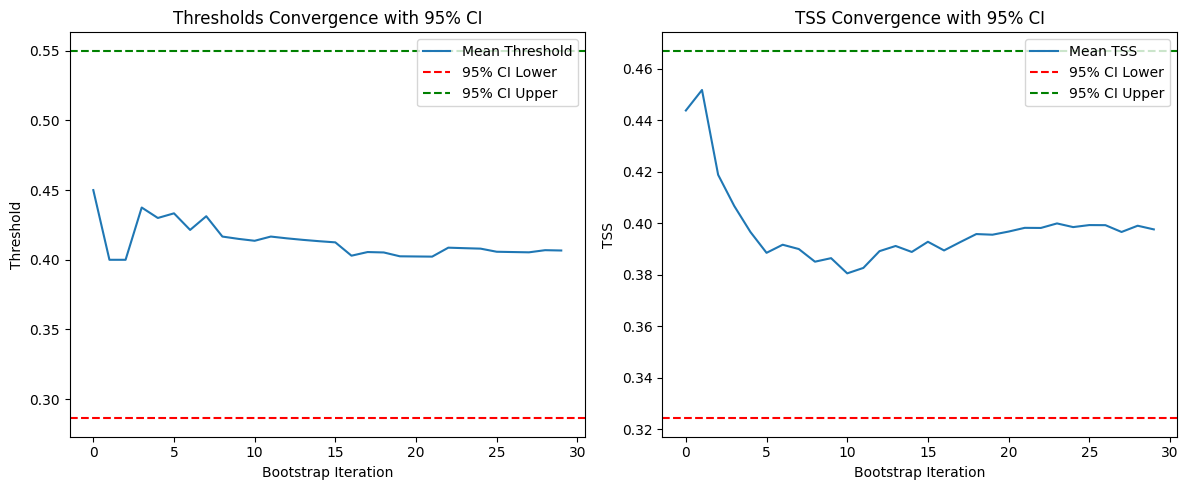

In [90]:
logistic_lead6_Task2_opr_nrt = train_logistic(pos_weight=2.0)
logistic_lead6_Task2_opr_nrt.train_logistic(lead6_opr_nrt.inputs_profile, lead6_opr_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [91]:
save_dir = ".\\Logreg_models\\Task2_opr_nrt_models"

for i, model in enumerate(logistic_lead6_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead6_Task2_opr_nrt{i}_{np.round(np.mean(logistic_lead6_Task2_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 302 positives and 604 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 302 positives, 604 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

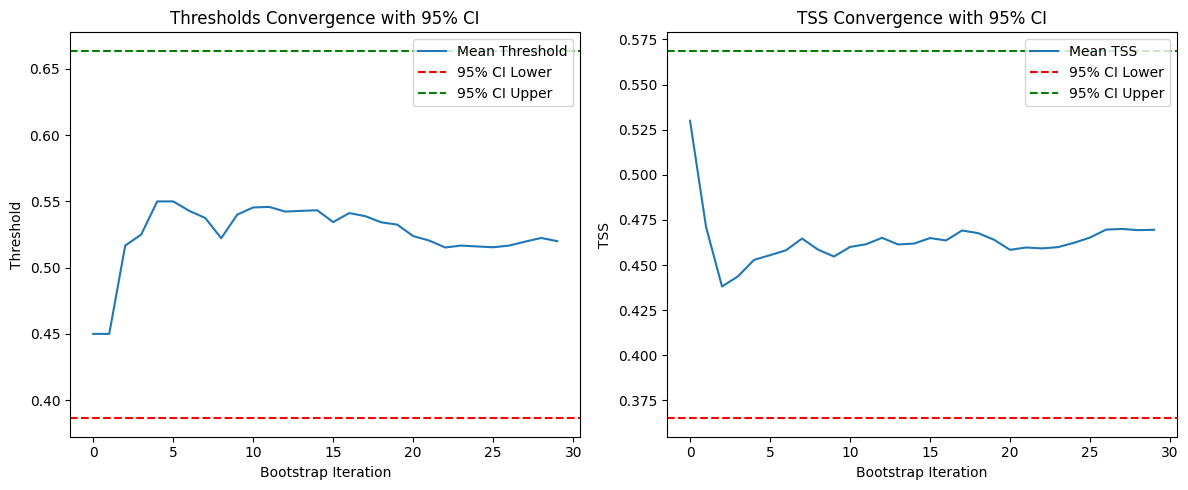

In [92]:
logistic_lead12_Task2_sci_nrt = train_logistic(pos_weight=2.0)
logistic_lead12_Task2_sci_nrt.train_logistic(lead12_sci_nrt.inputs_profile, lead12_sci_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [93]:
save_dir = ".\\Logreg_models\\Task2_sci_nrt_models"

for i, model in enumerate(logistic_lead12_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead12_Task2_sci_nrt{i}_{np.round(np.mean(logistic_lead12_Task2_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 239 positives and 478 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 239 positives, 478 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

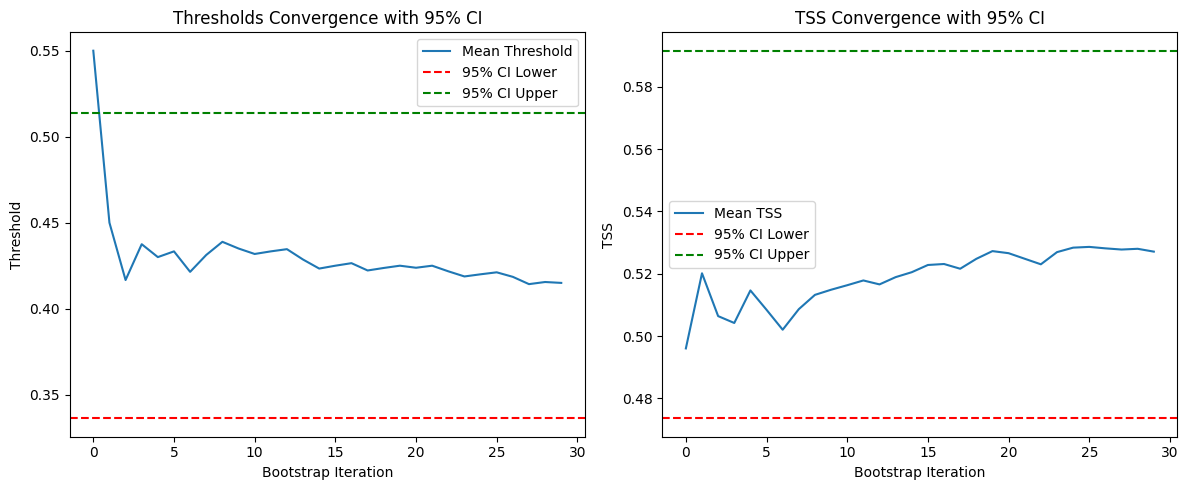

In [94]:
logistic_lead12_Task2_opr_nrt = train_logistic(pos_weight=2.0)
logistic_lead12_Task2_opr_nrt.train_logistic(lead12_opr_nrt.inputs_profile, lead12_opr_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [95]:
save_dir = ".\\Logreg_models\\Task2_opr_nrt_models"

for i, model in enumerate(logistic_lead12_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead12_Task2_opr_nrt{i}_{np.round(np.mean(logistic_lead12_Task2_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 284 positives and 568 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 284 positives, 568 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

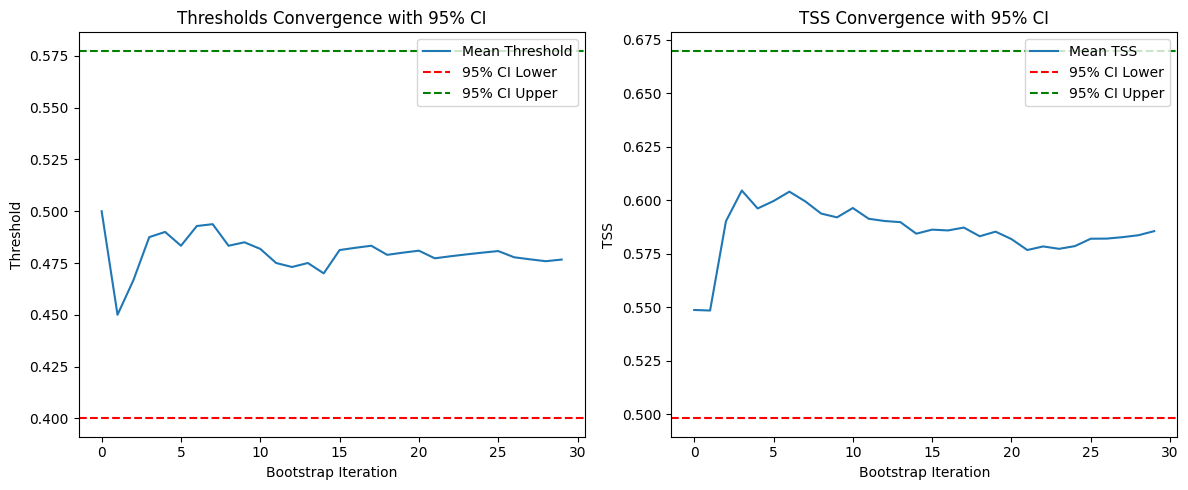

In [96]:
logistic_lead24_Task2_sci_nrt = train_logistic(pos_weight=2.0)
logistic_lead24_Task2_sci_nrt.train_logistic(lead24_sci_nrt.inputs_profile, lead24_sci_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [97]:
save_dir = ".\\Logreg_models\\Task2_sci_nrt_models"

for i, model in enumerate(logistic_lead24_Task2_sci_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead24_Task2_sci_nrt{i}_{np.round(np.mean(logistic_lead24_Task2_sci_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)

Using negative sampling with 2 negatives per positive.
Each bootstrap will use 219 positives and 438 negatives.
Bootstrap iteration 1/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 2/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 3/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 4/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 5/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 6/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 7/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 8/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 9/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 10/30
Bootstrap sample: 219 positives, 438 negatives; ratio=2.0000
Bootstrap iteration 11/30
B

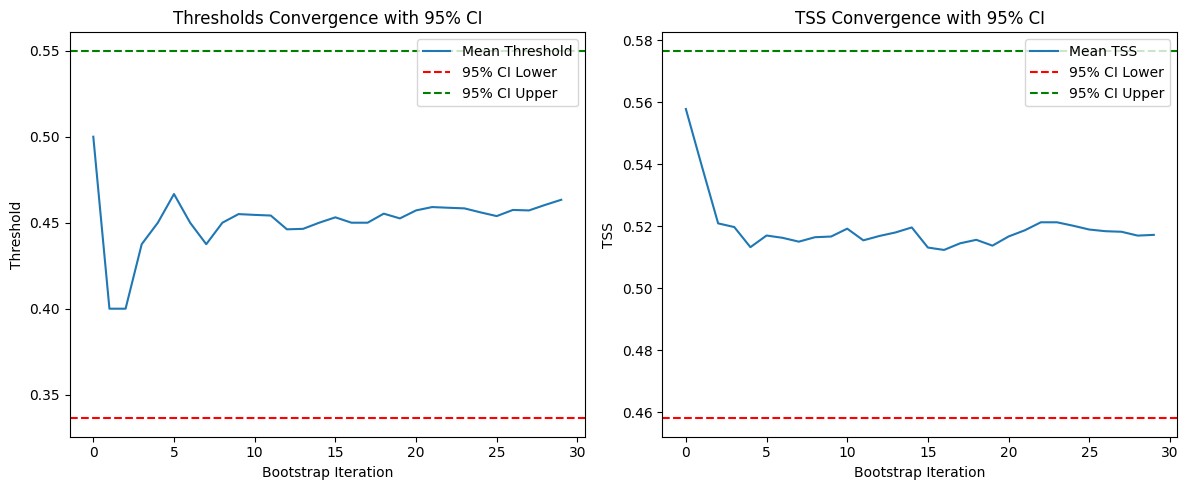

In [98]:
logistic_lead24_Task2_opr_nrt = train_logistic(pos_weight=2.0)
logistic_lead24_Task2_opr_nrt.train_logistic(lead24_opr_nrt.inputs_profile, lead24_opr_nrt.labels, "Task2", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'))

In [99]:
save_dir = ".\\Logreg_models\\Task2_opr_nrt_models"

for i, model in enumerate(logistic_lead24_Task2_opr_nrt.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, 
                              f"logistic_lead24_Task2_opr_nrt{i}_{np.round(np.mean(logistic_lead24_Task2_opr_nrt.thresholds),2)}.pth")
    joblib.dump(model, model_path)